# prototype_5_narrative_tool_colab_version
## Google Colab version for Story Propagation & Influencer Network Tool (SPIN)

***
***
## IMPORTS LIBRARIES BLOCK
Imports core utilities: regex, file paths, JSON, hashing, typing.

Imports data + math stack: NumPy, pandas, matplotlib, PyTorch.
Imports NLP + ML pieces:
  - TfidfVectorizer, cosine_similarity for text features and tweet–article similarity.
  - KMeans + silhouette_score for building and evaluating narrative clusters.
  - SentenceTransformer for dense embeddings (and to use GPU if available).

Imports optional analysis tools:
- networkx for graph-based analysis (e.g., diffusion networks, centrality).
- ruptures (if installed) for change-point detection in narrative timelines.

suppresses noisy font warnings

In [ ]:
# -------------------- IMPORTS LIBRARIES BLOCK----------------------------------
import re # regex cleaning (URLs/handles/punct)
import os # env vars & file paths
import json # write/read small config/metadata files (embedding cache info)
import hashlib # make stable cache keys (hash of text+model) for saved embeddings.
from pathlib import Path # Path-safe file handling across operating systems
from typing import Optional

import numpy as np # numeric ops, arrays, vector math
import pandas as pd
import matplotlib.pyplot as plt
import torch # Detect GPU and run SentenceTransformer embeddings on CUDA if available

from sklearn.feature_extraction.text import TfidfVectorizer # Build TF-IDF matrix for lexical similarity and for labeling clusters by top terms
from sklearn.metrics.pairwise import cosine_similarity # Compute cosine similarity between tweet vectors and article vectors (matching).
from sklearn.cluster import KMeans # K-means to form narrative clusters over embeddings
from sklearn.metrics import silhouette_score # Quality metric to auto-pick K (when K_NARR_FIXED is None) by maximizing average silhouette.

from sentence_transformers import SentenceTransformer # Pretrained models to generate dense sentence embeddings.

# Optional graph / change-point libs (kept for the pipeline)
import networkx as nx # Build/analyze graphs (author→outlet, URL diffusion) and compute centralities.
try:
    import ruptures as rpt  # ruptures enables optional change-point detection in narrative time series.
    HAS_RUPTURES = True # Wrap in try/except so the code will still runs when the lib isn’t installed
except Exception:
    HAS_RUPTURES = False

# stop displaying Glyph .* missing from font warnign message
import warnings
warnings.filterwarnings("ignore", message="Glyph .* missing from font")

#-------------------------------------------------------------------------------

***
***
# USER PATHS BLOCK (Enter the names of your tweets and media data files here)
- Defines where the tool will read input data from and where it will save outputs and caches.
- Sets the file paths for the tweet and media datasets the tool should ingest.
- Creates an output directory (output/) where results (leaderboards, clusters, plots, etc.) will be written.
- Creates a cache directory (cache/) to store reusable items like text embeddings and NER results, so the tool runs faster on repeated executions.

In [ ]:
# -------------------- USER PATHS BLOCK-----------------------------------------
# Create path objects (with relative paths) pointing to input in the present working directory

# input tweet and media data (ENTER YOUR TWEETS AND MEDIA DATA FILE NAMES HERE)
tweets_path = Path("PENTA_tweets_JUN2025_SEP_2025.xlsx")
media_path = Path("PENTA_media_JUN2025_SEP_2025.xlsx")
#--------------------------------------------------------

out_dir = Path("output")
out_dir.mkdir(parents=True, exist_ok=True)

# Root folder for all caches (embeddings + NER)
CACHE_ROOT = Path("cache")
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
#-------------------------------------------------------------------------------

***
***
# DATE FILTER BLOCK and USER TUNABLE PARAMETERS IN PLANNED DASHBOARD BLOCK

Sets the key user knobs (with knob defaults) for analysis from the planned streamlit dashboard for SPIN:

Date filters:
  - Defines a default analysis window (YYYY-MM-DD to YYYY-MM-DD).
  - ENTER YOUR DATE RANGE FOR ANALYSIS HERE.
  - override those dates with environment variables (NARR_DATE_START, NARR_DATE_END) without editing the code.

Text preprocessing settings:
   - MIN_DF, MAX_DF, NGRAM_RANGE control how TF-IDF builds features and how noisy/common terms are filtered.

Tweet→media matching rules:
  - WINDOW_DAYS, SIM_THRESHOLD, TOPK_PER_TWEET define when and how strongly tweets can be matched to articles.

Leaderboard thresholds:
  - MIN_OUTLETS_STD, MIN_OUTLETS_STRICT, MIN_TWEETS control what counts as a meaningful cross-media “hit” and which authors are included.

In [ ]:
# ----------------------- DATE FILTER BLOCK-------------------------------------
# ENTER YOUR START AND END DATES HERE
start_date_default = "2025-06-01" # start date (yyyy-mm-dd)
end_date_default = "2025-09-15" # end date (yyy-mm-dd)
#-------------------------------------------------------------

# Read environment variables (If an env var is set, it overrides the default. If not, the default is used.)
DATE_START = os.getenv("NARR_DATE_START", start_date_default)
DATE_END = os.getenv("NARR_DATE_END", end_date_default)
#--------------------------------------------------------

# -----USER TUNABLE PARAMETERS IN PLANNED DASHBOARD BLOCK----
# Text preprocessing
MIN_DF = 5 # Ignore terms that appear in fewer than 5 documents. Removes rare/noisy words that don’t generalize.(raise if there are many documents and lower if corpus is small)
MAX_DF = 0.80 # Ignore terms that appear in more than 80% of documents (too common to be informative). Tighten to 0.6–0.7 to make topics crisper; loosen if narratives look too fragmented.
NGRAM_RANGE = (1, 2) # Use unigrams and bigrams in TF-IDF. Bigrams capture phrases like “social security”

# Matching rules
WINDOW_DAYS = 7 # Only match a tweet to articles published within 7 days after it. Controls what “amplification” means temporally.
SIM_THRESHOLD = 0.30 # Minimum similarity to consider a text match. Raise to reduce false positives; lower to catch looser paraphrases.
TOPK_PER_TWEET = 3 # Cap the number of media matches per tweet; keeps results focused and speeds downstream aggregation.

# Leaderboards
MIN_OUTLETS_STD = 1 # threshold for counting a cross-media “hit” on the standard leaderboard. (any pickup by at least one outlet counts as a hit)
MIN_OUTLETS_STRICT = 2 # a tweet must be picked up by 2+ distinct outlets to count (more conservative leaderboard.)(decide whether a tweet truly “broke out” across multiple outlets.)
MIN_TWEETS = 3 # Minimum tweets per author to appear on the leaderboard—filters one-offs.
#-------------------------------------------------------------------------------


***
***
# EMBEDDINGS MODELS BLOCK
Controls which sentence-embedding model the tool uses and how fast/accurate it should be:
  - Defines a default high-quality model (all-MiniLM-L6-v2) and a faster, lighter model (paraphrase-MiniLM-L3-v2).
  - SPEED_MODE is a simple switch to favor speed over accuracy, and EMBED_MODEL_NAME (env var) can override everything.
  - The logic then picks the effective model and prints out what’s actually being used so you can verify the setting.


In [ ]:
#---------------------EMBEDDINGS MODELS BLOCK-----------------------------------

# SELECTABLE BY USER
# ---------- EMBEDDING SPEED CONTROL USER INPUT----------
# True: USE FASTER LESS ACCURATE MODEL (paraphrase-MiniLM-L3-v2)
# False: USE SLOWER MORE ACCURATE EMBEDDINGS MODEL (all-MiniLM-L6-v)
SPEED_MODE = False  # one switch to go faster
#-------------------------------------------------------

DEFAULT_MODEL = "all-MiniLM-L6-v2"# quality
FAST_MODEL = "paraphrase-MiniLM-L3-v2"# speed

ENV_MODEL = os.getenv("EMBED_MODEL_NAME", "").strip()  # explicit override wins

CONFIGURED_MODEL = ENV_MODEL or DEFAULT_MODEL
MODEL_EFFECTIVE  = (CONFIGURED_MODEL
                    if ENV_MODEL
                    else (FAST_MODEL if (SPEED_MODE and CONFIGURED_MODEL == DEFAULT_MODEL)
                          else CONFIGURED_MODEL))

print(f"[emb] configured={CONFIGURED_MODEL} | effective={MODEL_EFFECTIVE} | SPEED_MODE={SPEED_MODE}")
#-------------------------------------------------------------------------------

[emb] configured=all-MiniLM-L6-v2 | effective=all-MiniLM-L6-v2 | SPEED_MODE=False


***
***
# (FIXED) PARAMETERS BLOCK
Sets all the fixed, lower-level system parameters that control performance, clustering behavior, similarity matching, and narrative-propagation analysis across the entire pipeline.

These parameters will not be adjusted from the streamlit dashboard by the user and will only get adjusted in the back-end code.

1. Embedding performance + safety controls
  - EMBED_MAX_CHARS – limits how much text goes into each embedding.
  - EMBED_FP16_DISK – stores embeddings in smaller files (float16).
  - USE_ST_MULTIPROCESS – speed up CPU embedding.
  - SKIP_EMB_FOR_NARR_IF_CPU_BIG – if no GPU and dataset is huge, fall back to TF-IDF clustering.

2. Embedding batch sizes
  - EMBED_BATCH_GPU / EMBED_BATCH_CPU – tune how many documents are encoded per batch for stability and speed.

3. Narrative clustering
  - Control whether clustering uses embeddings or TF-IDF (USE_EMBEDDINGS_FOR_NARR).
  - Choose fixed K or auto-K (K_NARR_FIXED, K_AUTO_MIN, K_AUTO_MAX).

4. Similarity matching configuration
- Enable hybrid semantic + lexical similarity (USE_EMBEDDINGS_FOR_MATCH).
- Set blend weight between embeddings and TF-IDF (HYBRID_EMBED_WT).

5. Influencer clustering
  - K_INF_MAX caps the number of clusters when grouping authors by narrative behavior.

6. Narrative propagation (time-series analysis)
  - TS_FREQ, ROLL_DAYS, Z_THRESH define how you detect spikes.
  - USE_CHANGEPOINTS, CP_MODEL, CP_PENALTY enable structural shift detection when ruptures is installed.

7. Graph analysis
  - COMPUTE_BETWEENNESS optionally calculates betweenness centrality for diffusion networks.

In [ ]:
# -------------------- (FIXED) PARAMETERS BLOCK --------------------------------
# ---------- EMBEDDING SPEED CONTROL FIXED INPUT----------
EMBED_MAX_CHARS = 800  # 512 chars ~= ~250 tokens; good default (consider 800 for better semantic context)
EMBED_FP16_DISK = True # save .npy as float16; cast to float32 on load
USE_ST_MULTIPROCESS = True  # multi-process encode on CPU
SKIP_EMB_FOR_NARR_IF_CPU_BIG = 40000  # if no CUDA and docs > this, cluster on TF-IDF

# ----------WORD EMBEDDINGS MODEL CONFIG --------------------
EMBED_BATCH_GPU = 256 # how many documents to encode per forward pass when a GPU is available (GPUs handle larger batches efficiently, 256 gives good throughput without usually running out of VRAM.)
EMBED_BATCH_CPU = 64 # The batch size when running on CPU. Smaller batches prevent RAM spikes and keep the process stable.
#-----------------------------------------------------------

# Narrative clustering
USE_EMBEDDINGS_FOR_NARR = True # if True, Cluster on sentence embeddings (semantic) instead of TF-IDF (lexical). Usually yields better, more coherent narratives.
# Narrative clustering
K_NARR_FIXED = None  # <— set to an int to force K; None = auto-pick (If None, the script auto-picks K with silhouette score. Set to an integer (e.g., 8 or 12) to force a fixed number of clusters for stability)
K_AUTO_MIN, K_AUTO_MAX = 6, 14 # Search range for auto-K. Widen if topic space is broad and narrow for faster runs or steadier K.

# Similarity matching (hybrid TF-IDF + Embeddings)
USE_EMBEDDINGS_FOR_MATCH = True # if True, use semantic similarity for cross-media matching in addition to TF-IDF
HYBRID_EMBED_WT = 0.50 # Blend weight between TF-IDF and embeddings. (S = 0.5*embed + 0.5*tfidf.) Increase toward 0.7–0.9 if wording varies a lot; decrease if exact wording/keywords matter.

# Influencer clustering (author × narrative mix)
K_INF_MAX = 10 # Max number of clusters when grouping authors by their narrative portfolio (safety cap on the number of influencer clusters to prevent too much noise)

# -------- Narrative Propagation config ----------
TS_FREQ = "D" # Time-series sampling frequency. "D" aggregates counts per day (e.g., tweets/media per cluster per day).Switch to "W" for weekly smoothing.
ROLL_DAYS = 14 # Window size for rolling statistics (mean/std) used to spot surges. A 14-day window smooths short noise while still catching meaningful upticks.
Z_THRESH = 2.0 # Spike flagging threshold. If the rolling z-score ≥ 2, that date is marked as a surge (about 2 standard deviations above the recent baseline).
USE_CHANGEPOINTS = True # If ruptures is installed, also run change-point detection to find structural shifts (level/regime changes) in the time series, not just spikes.
CP_MODEL = "l2" # The cost model for ruptures (squared error). Good default for count-like series where you expect mean shifts.
CP_PENALTY = 3.5 # Regularization controlling how many change-points are accepted. Higher → fewer, more conservative change-points; lower → more sensitive.

COMPUTE_BETWEENNESS = False # In graph analysis (author→outlet, URL diffusion), whether to compute betweenness centrality.Informative but slow on large graphs, so default is off. Turn on if graphs are modest or specifically need bridge-finder nodes.
#-------------------------------------------------------------------------------

***
***
# HELPER FUNCTIONS BLOCK
Defines general-purpose helper functions that clean data and make the rest of the pipeline safer and easier to write:
  - to_dt / _parse_date_utc – standardize messy date strings into UTC datetimes.
  - clean_text – lightly normalize text (remove newlines, extra spaces).
  - load_excel_first_sheet – read the first sheet of any Excel file into a DataFrame.
  - series_or_default / num_or_default – safely grab a column if it exists, or create a default series if it doesn’t (prevents KeyErrors and keeps shapes aligned).
  - filter_date_range – apply an inclusive date filter to any DataFrame and log how many rows were kept.

In [ ]:
# ---------------------- HELPER FUNCTIONS BLOCK---------------------------------

# Standardizes any date-like input to a timezone-aware UTC datetime64 using pandas.to_datetime.
def to_dt(s):
    return pd.to_datetime(s, errors="coerce", utc=True)

# Light text normalizer for bodies/headlines
def clean_text(s: str) -> str:
    s = str(s)
    s = re.sub(r"[\n\r]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

# Opens an Excel file with openpyxl and returns the first sheet as a DataFrame.
def load_excel_first_sheet(path: Path) -> pd.DataFrame:
    xls = pd.ExcelFile(path, engine="openpyxl")
    return pd.read_excel(xls, sheet_name=xls.sheet_names[0])

# Safe column getter:If col exists, return it; otherwise return a Series filled with default (right length & dtype).
# Prevents KeyErrors and keeps downstream shapes aligned.
def series_or_default(df: pd.DataFrame, col: Optional[str], default, dtype="object"):
    if col is not None and col in df.columns:
        return df[col]
    return pd.Series([default] * len(df), index=df.index, dtype=dtype)

# numeric version of safe column getter
# If present, coerce to numeric (bad values → NaN) and fill with default.
# If missing, create a numeric Series of default.
def num_or_default(df: pd.DataFrame, col: Optional[str], default=0.0):
    if col is not None and col in df.columns:
        return pd.to_numeric(df[col], errors="coerce").fillna(default)
    return pd.Series([default] * len(df), index=df.index, dtype="float")

# Parse a single string-like date into UTC or returns None if empty/invalid.
def _parse_date_utc(s: Optional[str]):
    if s is None:
        return None
    s = str(s).strip()
    if not s:
        return None
    dt = pd.to_datetime(s, errors="coerce", utc=True)
    return None if pd.isna(dt) else dt

# Inclusive time filter on any DataFrame:
def filter_date_range(df: pd.DataFrame, start=None, end=None, time_col="time", name=""):
    out = df.copy()
    out[time_col] = to_dt(out[time_col])
    n0 = len(out)
    if start is not None:
        out = out[out[time_col] >= start]
    if end is not None:
        out = out[out[time_col] <= end]
    if name:
        print(f"[date-filter] {name}: {n0} -> {len(out)} rows "
              f"(start={start if start is not None else '—'}, end={end if end is not None else '—'})")
    return out
#-------------------------------------------------------------------------------

***
***
# NORMALIZATION BLOCK
Standardizes the raw tweet and media tables into one common schema so the rest of the pipeline can treat them uniformly.

Converts heterogeneous tweet/media input files into a single, clean, unified format the narrative and influencer logic can work on.

normalize_tweets(...):
  - Picks/renames columns into a consistent set: doc_id, _text, title, author, time, outlet, url, engagement, sentiment.
  - Cleans the text fields.
  - Uses article_body when available, otherwise falls back to headline.
  - Tags every row with _kind = "tweet".

normalize_media(...):
  - Does the same but for news articles.
  - Concatenates headline + article_body into _text.
  - Tags every row with _kind = "media".

In [ ]:
# ----------------- NORMALIZATION BLOCK-----------------------------------------
def normalize_tweets(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    out["doc_id"] = series_or_default(df, "source_unique_id", np.nan, dtype="object").astype(str)
    body = series_or_default(df, "article_body", "").astype(str)
    head = series_or_default(df, "headline", "").astype(str)
    text = body.where(body.str.strip() != "", head)
    out["_text"] = text.map(clean_text)
    out["title"] = head.map(clean_text)
    out["author"] = series_or_default(df, "author_name", "unknown").astype(str)
    out["time"] = to_dt(series_or_default(df, "published_datetime", np.nan))
    if out["time"].isna().all() and "load_datetime" in df.columns:
        out["time"] = to_dt(df["load_datetime"])
    out["outlet"] = series_or_default(df, "publication_name",
                      series_or_default(df, "publisher_name", "unknown")).astype(str)
    out["url"] = series_or_default(df, "article_url", "").astype(str)
    out["_kind"] = "tweet"
    out["engagement"] = num_or_default(df, "engagement", np.nan)
    out["sentiment"] = num_or_default(df, "sentiment_score", np.nan)
    return out

def normalize_media(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    out["doc_id"] = series_or_default(df, "source_unique_id", np.nan, dtype="object").astype(str)
    head = series_or_default(df, "headline", "").astype(str)
    body = series_or_default(df, "article_body", "").astype(str)
    out["title"] = head.map(clean_text)
    out["_text"] = (head + " " + body).map(clean_text)
    out["author"] = series_or_default(df, "author_name", "").astype(str)
    out["time"] = to_dt(series_or_default(df, "published_datetime", np.nan))
    if out["time"].isna().all() and "load_datetime" in df.columns:
        out["time"] = to_dt(df["load_datetime"])
    out["outlet"] = series_or_default(df, "publication_name",
                      series_or_default(df, "publisher_name", "unknown")).astype(str)
    out["url"] = series_or_default(df, "article_url", "").astype(str)
    out["_kind"] = "media"
    out["engagement"] = num_or_default(df, "engagement", np.nan)
    out["sentiment"] = num_or_default(df, "sentiment_score", np.nan)
    return out
#-------------------------------------------------------------------------------

***
***
# LOAD DATA AND NORMALIZE DATA BLOCK
Loads the input files and converts them into the unified format:
  - Reads the raw Excel files for tweets and media into DataFrames (tweets_raw, media_raw).
  - Runs them through the normalization functions to produce:
    - t = cleaned, standardized tweet table.
    - m = cleaned, standardized media table.


In [ ]:
# -----------LOAD DATA AND NORMALIZE DATA BLOCK --------------------------------
tweets_raw = load_excel_first_sheet(tweets_path)
media_raw  = load_excel_first_sheet(media_path)

# normalize tweet and media data into a common schema
t = normalize_tweets(tweets_raw) #normalized tweet object (t)
m = normalize_media(media_raw) # normalized media object (m)
#-------------------------------------------------------------------------------

***
***
# APPLY DATE FILTER BLOCK
Cuts the tweet and media data down to the time window entered by the user for analysis:
  - Converts the configured DATE_START and DATE_END into proper UTC datetimes.
  - Filters tweets (t) and media (m) so only rows within that date range remain.
  - Prints how many rows were kept for each, and raises an error if everything gets filtered out.

In [ ]:
# ------------------ APPLY DATE FILTER BLOCK------------------------------------
# Keeps analyses scoped to a specific period (e.g., a campaign window).
_start = _parse_date_utc(DATE_START)
_end   = _parse_date_utc(DATE_END)
if (_start is not None) or (_end is not None):
    t = filter_date_range(t, start=_start, end=_end, time_col="time", name="tweets")
    m = filter_date_range(m, start=_start, end=_end, time_col="time", name="media")
    if t.empty and m.empty:
        raise ValueError("After applying the date range, both tweets and media are empty.")
# ------------------------------------------------------------------------------

[date-filter] tweets: 271653 -> 269877 rows (start=2025-06-01 00:00:00+00:00, end=2025-09-15 00:00:00+00:00)
[date-filter] media: 11124 -> 10961 rows (start=2025-06-01 00:00:00+00:00, end=2025-09-15 00:00:00+00:00)


***
***
# REMOVE LIKLEY MEDIA OUTLETS BLOCK
Filters out news organizations from the tweet side so the “influencers” are people, not outlets:
  - Uses a regex and a list (MEDIA_ALWAYS) to flag author names that look like media brands (e.g., “NYTimes”, “BBCNews”, “FoxNews”).
  - Protects true user handles that start with @ so they aren’t accidentally dropped.
  - Marks those rows as is_media_account and removes them from the tweets (tweets_nf), keeping only non-media accounts.
  - If that filter wipes everything out, it falls back and keeps all tweets (with a warning).

In [ ]:
#---------------REMOVE LIKLEY MEDIA OUTLETS BLOCK-------------------------------
# ---- Remove likely media outlets from the tweet side ----
# Filter obvious media accounts ONLY on tweet side (preserve @handles)
# identify individual influencers vs. institutional media. Many “tweets” are actually outlet posts syndicated to X; filtering them avoids inflating “influencers” with organizations.
MEDIA_HANDLE_RE = re.compile(
    r"\b(?:news|daily|times|post|tribune|herald|gazette|press|journal|sun|globe|enquirer|chronicle|report|ledger|observer|standard|publicradio|today|wsj|nytimes|nyt|guardian|reuters|ap|associatedpress|bloomberg|politico|axios|npr|pbs|cbc|bbc|telegraph|financialtimes|economist|forbes|usatoday|latimes|washingtonpost|cbs|abc|nbc|fox|cnn|msnbc|cspan|cnbc|vox|time|theatlantic|newyorker|independent|skynews)\b",
    flags=re.IGNORECASE,
)
MEDIA_ALWAYS = {
    "thehill","cbsnews","abcnews","nbcnews","foxnews","ap","reuters","nytimes",
    "washingtonpost","wsj","latimes","usatoday","politico","axios","bloomberg",
    "npr","pbs","bbcnews","guardian","ft","economist","forbes","cnbc","msnbc","cnn"
}

author_lc = t["author"].str.lower().fillna("")
looks_like_outlet = author_lc.isin(MEDIA_ALWAYS) | author_lc.str.contains(MEDIA_HANDLE_RE, na=False)
has_at_handle = t["author"].str.startswith("@", na=False)
t["is_media_account"] = looks_like_outlet & ~has_at_handle

tweets_nf = t.loc[~t["is_media_account"]].copy()
if tweets_nf.empty:
    print("[WARN] All tweets filtered by outlet heuristic; relaxing filter but keeping @handle protection.")
    tweets_nf = t.copy()
    tweets_nf["is_media_account"] = False
#-------------------------------------------------------------------------------

***
***
# BUILD UNIFIED CORPUS BLOCK
Builds the single master dataset (tweets + media) the whole analysis runs on:
  - Concatenates the cleaned tweets (people only) and media articles into one unified corpus with the same columns: _text, author, time, doc_id, outlet, url, _kind, engagement, sentiment.
  - Creates a boolean masks to tell tweets from media (tweet_mask, media_mask).
  - Adds a safety check: if there’s no usable text left, it raises an error so you don’t silently run the pipeline on empty content.

In [ ]:
#---------------------BUILD UNIFIED CORPUS BLOCK--------------------------------
# ---- Build a unified analysis corpus and validate it ----
# Combine corpus
corpus = pd.concat(
    [
        tweets_nf[["_text","author","time","doc_id","outlet","url","_kind","engagement","sentiment"]],
        m[["_text","author","time","doc_id","outlet","url","_kind","engagement","sentiment"]],
    ],
    ignore_index=True
)

# masks
tweet_mask = corpus["_kind"].eq("tweet")
media_mask = corpus["_kind"].eq("media")

# Guard
if corpus["_text"].str.strip().replace("", np.nan).dropna().empty:
    raise ValueError("No textual content after normalization—check mappings.")
#-------------------------------------------------------------------------------

***
***
# PRE-IDF CLEANER + STOPWORD BLOCK
Prepares the text specifically for TF-IDF by cleaning and removing noise.
  - Defines a custom bilingual stopword list (English + Spanish + platform junk like rt, http, breaking, etc.).
  - pre_tfidf_clean:
    - lowercases text, removes URLs, strips @ and #,
    - removes non-alphanumeric symbols,
    - drops very short tokens and anything in CUSTOM_STOPS.
  - Creates a new column corpus["_text_clean"] that holds this cleaned text just for TF-IDF, while leaving the original _text untouched for embeddings, exports, etc.

In [ ]:
#--------------- PRE-IDF CLEANER + STOPWORD BLOCK-------------------------------
# =========================================================
# Pre-TF-IDF cleaner + bilingual stopwords BLOCK
# =========================================================
# curated stoplist that goes beyond scikit-learn’s defaults
CUSTOM_STOPS = {
    # platform / boilerplate
    "http","https","amp","com","co","t","rt","via","www","subscribe","watch","read",
    "breaking","update","thread",
    # English extras
    "said","says","today","yesterday","tomorrow",
    # Spanish common stops
    "de","la","que","el","en","y","a","los","del","se","las","por","un","para","con",
    "no","una","su","al","lo","como","más","pero","sus","le","ya","o","este","sí",
    "porque","esta","entre","cuando","muy","sin","sobre","también","me","hasta",
    "hay","donde","quien","desde","todo","nos","durante","todos","uno","les",
    "ni","contra","otros","ese","eso","ante","ellos","e","esto","mí","antes",
    "algunos","qué","unos","yo","otro","otras","otra","él","tanto","esa","estos",
    "mucho","quienes","nada","muchos","cual","poco","ella","estar","estas","algunas",
    "algo","nosotros","mi","mis","tú","te","ti","tu","tus","ellas","nosotras",
    "vosotros","vosotras","os","mío","mía","míos","mías","tuyo","tuya","tuyos","tuyas",
    "suyo","suya","suyos","suyas","nuestro","nuestra","nuestros","nuestras","vuestro",
    "vuestra","vuestros","vuestras","esos","esas","estoy","estás","está","estamos",
    "estáis","están","esté","estés","estemos","estéis","estén"
}

# A lightweight normalizer executed before TF-IDF
def pre_tfidf_clean(s: str) -> str:
    s = str(s).lower()
    s = re.sub(r"https?://\S+", " ", s)  # remove URLs
    s = re.sub(r"[@#]", " ", s)  # strip @ and #
    s = re.sub(r"[^a-z0-9'\s-]", " ", s)   # keep words/digits/'/space/-
    s = re.sub(r"\s+", " ", s).strip()
    tokens = [w for w in s.split() if len(w) > 1 and w not in CUSTOM_STOPS]
    return " ".join(tokens)

# Creates a cleaned text column used for TF-IDF vectorization (leaving the original _text intact for other steps like embeddings, exporting, or URL extraction).
corpus["_text_clean"] = corpus["_text"].fillna("").map(pre_tfidf_clean)
#-------------------------------------------------------------------------------

***
***
# FIT TF-IDF BLOCK
Builds the TF-IDF representation of the cleaned corpus, which will be used later for clustering, labeling, and similarity:
  - Configures a TfidfVectorizer with the tunable knobs (MIN_DF, MAX_DF, NGRAM_RANGE) plus English stopwords and other options (accent folding, log-scaling, L2 norm, vocab cap).
  - Fits it on corpus["_text_clean"] and transforms the text into a sparse matrix X_tfidf.
  - Saves the corresponding feature_names so you can later see which words/phrases are important in each narrative.

In [ ]:
#------------------------ FIT TF-IDF BLOCK--------------------------------------
# =========================================================
# Refit TF-IDF on the cleaned text
# =========================================================
tfidf_vec = TfidfVectorizer(
    min_df=MIN_DF, # drop ultra-rare terms (≤ MIN_DF docs)
    max_df=MAX_DF, # drop overly common terms (≥ MAX_DF fraction of docs)
    ngram_range=NGRAM_RANGE, # include unigrams/bigrams
    stop_words="english",  # plus CUSTOM_STOPS via pre-clean
    strip_accents="unicode", # fold accents (e.g., “política” → “politica”)
    sublinear_tf=True, # use 1 + log(tf) (dampens very frequent terms)
    norm="l2", # L2-normalize vectors (helps cosine similarity)
    max_features=120_000 # cap vocab size for speed/memory (if RAM is tight, set to 80_000)
)
# Fit & transform on cleaned text
X_tfidf = tfidf_vec.fit_transform(corpus["_text_clean"])
# Store feature names
feature_names = np.array(tfidf_vec.get_feature_names_out())
#-------------------------------------------------------------------------------

***
***
# EMBEDDINGS MODEL BLOCK
Computes sentence embeddings efficiently and reuses them.
- Sets up a disk cache for embeddings:
  - Hashes each document’s text (_text_hashes) and stores (hash → vector) in cache_root/emb_cache_<model>/.
  - Later runs, it loads existing vectors and only encodes new texts.

- Handles fast, robust encoding:
  - Truncates text to EMBED_MAX_CHARS.
  - De-duplicates identical strings so each unique text is encoded once.
  - Uses multi-process encoding on CPU or standard .encode() on GPU with batch sizes tuned for each.
  - Stores embeddings as float16 on disk but returns float32 for downstream math.

- Adds safety/performance logic:
  - If there’s no GPU and the corpus is huge, it turns off embedding-based narrative clustering and falls back to TF-IDF.
  - If anything goes wrong loading/encoding embeddings, it disables embedding use for both clustering and matching (with a warning).

- Option to use embeddings for narrtive clustering:
  - USE_EMBEDDINGS_FOR_NARR = False (clustering is performed using TF-IDF)
  - USE_EMBEDDINGS_FOR_NARR = True (clustering is performed using embeddings)

In [ ]:
# ----------------- EMBEDDINGS MODEL BLOCK (FAST) ------------------------------
# Caching: incrementally store vectors by text-hash so new runs only
# compute embeddings for *new* texts. Also de-dup identical strings.

def _cache_dir(out_dir: Path, model_name: str) -> Path:
    # Ignore out_dir for cache location; use CACHE_ROOT instead
    d = CACHE_ROOT / f"emb_cache_{model_name.replace('/', '_')}"
    d.mkdir(parents=True, exist_ok=True)
    return d

def _text_hashes(texts: list[str]) -> np.ndarray:
    return np.array([hashlib.sha1(t.encode("utf-8")).hexdigest() for t in texts], dtype="U40")

def _save_cache(cache_dir: Path, hashes: np.ndarray, vecs: np.ndarray):
    # vecs can be float16 on disk; hashes saved as fixed-length Unicode
    np.save(cache_dir / "hashes.npy", hashes)
    np.save(cache_dir / "vecs.npy", vecs)

def _load_cache(cache_dir: Path) -> tuple[np.ndarray, np.ndarray]:
    h_p = cache_dir / "hashes.npy"
    v_p = cache_dir / "vecs.npy"
    if h_p.exists() and v_p.exists():
        hashes = np.load(h_p, allow_pickle=False)
        vecs   = np.load(v_p, allow_pickle=False)
        return hashes, vecs
    return np.array([], dtype="U40"), np.empty((0, 384), dtype="float16")  # 384 for MiniLM

def _ensure_fp32(a: np.ndarray) -> np.ndarray:
    return a.astype("float32", copy=False)

def _encode_texts(model, texts: list[str], batch_size: int, normalize: bool, device: str) -> np.ndarray:
    # Prefer sentence-transformers multi-process on CPU; plain .encode on GPU
    if device == "cpu" and USE_ST_MULTIPROCESS:
        try:
            pool = model.start_multi_process_pool()
            vecs = model.encode(texts, pool, batch_size=batch_size,
                                show_progress_bar=True, normalize_embeddings=normalize)
            model.stop_multi_process_pool(pool)
            return vecs
        except Exception:
            pass  # fall back below
    return model.encode(texts, batch_size=batch_size, show_progress_bar=True,
                        normalize_embeddings=normalize)

def compute_embeddings_fast(corpus: pd.DataFrame, model_name: str, out_dir: Path,
                            max_chars: int = 512, batch_gpu: int = 256, batch_cpu: int = 64,
                            normalize: bool = True, fp16_disk: bool = True) -> np.ndarray:
    # 1) Prepare texts (shorten + strip). Shorter = faster; keeps quality for MiniLMs.
    texts = corpus["_text"].fillna("").str.slice(0, max_chars).tolist()

    # 2) De-dup by content hash so we only encode unique strings once.
    all_hashes = _text_hashes(texts)
    uniq_hashes, inv = np.unique(all_hashes, return_inverse=True)  # inv maps each row -> unique index

    cache_dir = _cache_dir(out_dir, model_name)
    cache_hashes, cache_vecs = _load_cache(cache_dir)
    cache_map = {h: i for i, h in enumerate(cache_hashes)}

    # 3) Which unique hashes are missing from cache?
    missing_mask = np.array([h not in cache_map for h in uniq_hashes])
    need_hashes = uniq_hashes[missing_mask].tolist()

    device = "cuda" if torch.cuda.is_available() else "cpu"
    bs = batch_gpu if device == "cuda" else batch_cpu

    if len(need_hashes) > 0:
        print(f"[emb] need to encode {len(need_hashes):,} unique texts on {device} (batch={bs})")
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer(model_name, device=device)

        # Reconstruct the unique texts for these hashes
        # Build map hash -> text once (use the first occurrence)
        first_pos = {}
        for i, h in enumerate(all_hashes):
            if h not in first_pos:
                first_pos[h] = i
            if len(first_pos) == len(uniq_hashes):
                break
        need_texts = [texts[first_pos[h]] for h in need_hashes]

        new_vecs = _encode_texts(model, need_texts, batch_size=bs, normalize=normalize, device=device)
        new_vecs = np.asarray(new_vecs)
        if fp16_disk:
            new_vecs_disk = new_vecs.astype("float16", copy=False)
        else:
            new_vecs_disk = new_vecs.astype("float32", copy=False)

        # 4) Append to cache
        if cache_vecs.size == 0:
            new_hashes_all = np.array(need_hashes, dtype="U40")
            cache_hashes, cache_vecs = new_hashes_all, new_vecs_disk
        else:
            cache_hashes = np.concatenate([cache_hashes, np.array(need_hashes, dtype="U40")], axis=0)
            cache_vecs   = np.concatenate([cache_vecs,   new_vecs_disk], axis=0)
        _save_cache(cache_dir, cache_hashes, cache_vecs)
        # rebuild map
        cache_map = {h: i for i, h in enumerate(cache_hashes)}
        print(f"[emb] cache now has {len(cache_hashes):,} unique vectors")

    # 5) Assemble full E in corpus order from cache
    idxs = np.array([cache_map[h] for h in all_hashes], dtype=int)
    E = cache_vecs[idxs]
    # For sklearn cosine / KMeans, keep math in fp32
    E = _ensure_fp32(E)
    return E

# ---- Decide whether to use embeddings for narrative clustering -----
if USE_EMBEDDINGS_FOR_NARR and (not torch.cuda.is_available()) and (len(corpus) > SKIP_EMB_FOR_NARR_IF_CPU_BIG):
    print(f"[emb] CPU + large corpus ({len(corpus):,}); using TF-IDF for narrative clustering to speed up.")
    USE_EMBEDDINGS_FOR_NARR = False

# ---------- Compute or load embeddings fast ----------
E = None
if USE_EMBEDDINGS_FOR_NARR or USE_EMBEDDINGS_FOR_MATCH:
    try:
        model_name = MODEL_EFFECTIVE
        E = compute_embeddings_fast(
            corpus,
            model_name=model_name ,
            out_dir=out_dir,
            max_chars=EMBED_MAX_CHARS,
            batch_gpu=EMBED_BATCH_GPU,
            batch_cpu=EMBED_BATCH_CPU,
            normalize=True,
            fp16_disk=True
        )
    except Exception as e:
        print(f"[WARN] Embeddings disabled (error: {e}).")
        USE_EMBEDDINGS_FOR_NARR = False
        USE_EMBEDDINGS_FOR_MATCH = False
  #-----------------------------------------------------------------------------

[emb] need to encode 235,821 unique texts on cuda (batch=256)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/922 [00:00<?, ?it/s]

[emb] cache now has 235,821 unique vectors


***
***
# NARRATIVE CLUSTERING WITH AUTO-K BLOCK
Automatically groups all documents into narrative clusters in a RAM-friendly way and decides how many clusters (K) to use.
  - Sets memory-safe settings (sampling size, dimensionality reduction, MiniBatchKMeans options).
  - Chooses whether to cluster on embeddings or TF-IDF (X_cluster).

  - Uses TruncatedSVD/PCA plus a small sample to:
    - Try different K values,
    - Compute silhouette scores, and
    - Auto-pick the best K within [K_AUTO_MIN, K_AUTO_MAX].
- Reduces the full feature matrix and runs MiniBatchKMeans/KMeans to assign each document to a cluster.
- Stores the result in corpus["cluster"]

In [ ]:
#------------------NARRATIVE CLUSTERING WITH AUTO-K BLOCK-----------------------
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.metrics import silhouette_score
from sklearn.utils import check_random_state
import warnings
import numpy as np
import scipy.sparse as sp

# ---------------RAM controls (tweak here) --------
LOW_RAM_MODE  = True
AUTO_SAMPLE_MAX = 5000 # rows used for auto-K silhouette (keep small)
REDUCE_DIM  = 60  # target dimension for SVD/PCA before clustering
MB_BATCH_SIZE = 2048  # MiniBatchKMeans batch size
MB_INIT_SIZE = 3 * MB_BATCH_SIZE
KM_INIT  = 10  # n_init for KMeans/MiniBatchKMeans
# --------------------------------------------------

def _row_sample_idx(n_total, n_sample, seed=42):
    rng = check_random_state(seed)
    n_use = min(n_total, n_sample)
    return rng.choice(n_total, size=n_use, replace=False)

def _reduce_for_clustering(X, dim=REDUCE_DIM, seed=42):
    """
    Returns a RAM-friendly representation Z for clustering:
    - If X is sparse: TruncatedSVD(dim) -> float32 dense (n x dim)
    - If X is dense (e.g., embeddings): PCA(dim) -> float32 dense (n x dim)
    Never calls .toarray() on the full sparse matrix.
    """
    if sp.issparse(X):
        dim = min(dim, max(2, X.shape[1]-1))  # safety
        svd = TruncatedSVD(n_components=dim, random_state=seed)
        Z = svd.fit_transform(X).astype("float32", copy=False)
        return Z
    else:
        # X might already be dense embeddings (float32)
        dim = min(dim, max(2, X.shape[1]-1))
        pca = PCA(n_components=dim, random_state=seed)
        Z = pca.fit_transform(X).astype("float32", copy=False)
        return Z

def _reduce_for_silhouette_sample(X, idx, dim=REDUCE_DIM, seed=42):
    """
    Fit the reducer on a small subset for stability, then transform that same subset.
    Keeps memory low and avoids densifying the whole matrix.
    """
    if sp.issparse(X):
        # fit SVD only on sampled rows (sparse)
        Xs = X[idx]
        dim = min(dim, max(2, Xs.shape[1]-1))
        svd = TruncatedSVD(n_components=dim, random_state=seed)
        Zs = svd.fit_transform(Xs).astype("float32", copy=False)
        return Zs
    else:
        # dense case (embeddings)
        Xs = X[idx]
        dim = min(dim, max(2, Xs.shape[1]-1))
        pca = PCA(n_components=dim, random_state=seed)
        Zs = pca.fit_transform(Xs).astype("float32", copy=False)
        return Zs

def choose_k_by_silhouette_lowram(X, k_min=6, k_max=14, sample_max=AUTO_SAMPLE_MAX, dim=REDUCE_DIM, seed=42):
    """
    RAM-safe auto-K:
      1) Sample up to sample_max rows.
      2) Reduce to 'dim' dims (SVD/PCA) only on the sample.
      3) Run cheap KMeans on the sample + silhouette.
    """
    n_total = X.shape[0]
    idx = _row_sample_idx(n_total, sample_max, seed)
    Zs = _reduce_for_silhouette_sample(X, idx, dim=dim, seed=seed)

    best_k, best_score = None, -1.0
    for k in range(k_min, k_max + 1):
        try:
            km = KMeans(n_clusters=k, n_init=KM_INIT, random_state=seed)
            labels = km.fit_predict(Zs)
            if len(np.unique(labels)) < 2:
                continue
            score = silhouette_score(Zs, labels, metric="euclidean")
            if score > best_score:
                best_k, best_score = k, score
        except Exception:
            continue
    if best_k is None:
        best_k = max(2, min(20, k_min))
    return best_k, best_score

# ----------Choose features to cluster ---------
X_cluster = E if (USE_EMBEDDINGS_FOR_NARR and E is not None) else X_tfidf

# ----------- Auto-K (RAM-safe) ---------------
if K_NARR_FIXED is None:
    auto_k, auto_score = choose_k_by_silhouette_lowram(
        X_cluster, k_min=K_AUTO_MIN, k_max=K_AUTO_MAX,
        sample_max=AUTO_SAMPLE_MAX, dim=REDUCE_DIM, seed=42
    )
    k_narr = max(2, min(20, auto_k if auto_k is not None else 8))
    print(f"[cluster] Auto-picked K={k_narr} (silhouette≈{auto_score:.3f} on reduced sample)")
else:
    k_narr = max(2, min(20, K_NARR_FIXED))
    print(f"[cluster] Using fixed K={k_narr}")

# ----------- Final clustering (RAM-safe) ------
# Reduce full matrix first; then use MiniBatchKMeans on reduced (~n x REDUCE_DIM).
Z = _reduce_for_clustering(X_cluster, dim=REDUCE_DIM, seed=42)

if LOW_RAM_MODE:
    kmeans = MiniBatchKMeans(
        n_clusters=k_narr, batch_size=MB_BATCH_SIZE,
        init_size=MB_INIT_SIZE, n_init=KM_INIT, random_state=42
    )
else:
    kmeans = KMeans(n_clusters=k_narr, n_init=KM_INIT, random_state=42)

labels = kmeans.fit_predict(Z)
corpus["cluster"] = labels.astype(int)
#-------------------------------------------------------------------------------

[cluster] Auto-picked K=9 (silhouette≈0.048 on reduced sample)


***
***
# NAMED ENTITY RECOGNITION BLOCK
Finds the top people mentioned in each narrative cluster.
Identifies and ranks the key people associated with each narrative cluster, giving you “top influencers / figures per narrative” as a clean table

- Sets up NER config + cache so it can reuse results across runs and avoid re-processing the same texts.

- Uses spaCy PERSON NER when available, otherwise a regex-based extractor, plus:
  - Lots of heuristics and blocklists to filter out outlets, institutions, domain terms (“Medicare”, “Insurance”), URLs, IDs, etc.
  - A strict _is_likely_person / _clean_name pipeline so you mostly keep real person names.
- De-duplicates identical texts (retweets, syndication) so NER runs only once per unique text.
  - Extracts names from documents, links them back to clusters and doc_ids, then:
    - Aggregates counts per (cluster, person),
    - Ranks them by mentions and documents,
    - Keeps the top 25 names per cluster.

In [ ]:
#-------------NAMED ENTITY RECOGNITION BLOCK------------------------------------
# ==== Top people per narrative cluster (FAST) ======
import os, re, json, hashlib
import numpy as np
import pandas as pd
from collections import defaultdict

# -------------------- Config knobs --------------------
PREFILTER_REGEX = True  # quick regex gate before NER
SPACY_BATCH_SIZE = 256  # tune based on RAM
SPACY_NPROC = max(1, (os.cpu_count() or 2) - 1)

USE_NER_CACHE = False   # <--- turn caching OFF of ON

CACHE_DIR = CACHE_ROOT / "ner_cache"  # persistent cache
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# -------------------- Utilities --------------------
def _text_hash(s: str) -> str:
    return hashlib.sha1(s.encode("utf-8")).hexdigest()

def _load_cache_NER():
    if not USE_NER_CACHE:
        # no cache: always force spaCy/regex to run
        return {}
    path = CACHE_DIR / "names_cache.jsonl"
    m = {}
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                try:
                    obj = json.loads(line)
                    m[obj["h"]] = obj["names"]
                except Exception:
                    continue
    return m

def _append_cache_NER(items):
    if not USE_NER_CACHE or not items:
        return
    path = CACHE_DIR / "names_cache.jsonl"
    with open(path, "a", encoding="utf-8") as f:
        for h, names in items.items():
            f.write(json.dumps({"h": h, "names": names},
                               ensure_ascii=False) + "\n")


# -------------------- Name cleaning rules --------------------
NON_PERSON_BLOCKLIST = set(map(str.lower, [
    "united states","white house","supreme court","the hill","reuters","cnn","fox news",
    "the washington post","new york times","wall street journal","associated press","bloomberg",
    "house","senate","congress","nato","eu","uk","us","u.s.","gop","democrats","republicans",
    "fbi","cia","cdc","who","npr","bbc","ft","economist","politico","axios","latimes","usatoday", "legal disclaimer"
]))
ROLE_WORDS = {"president","senator","rep","representative","secretary","chair","ceo",
              "editor","host","governor","mayor","speaker","judge","dr","professor"}
FAMOUS_LASTNAMES = {"trump","biden","obama","clinton","zelenskyy","putin","netanyahu","modi","xi"}

# Domain terms frequently mis-tagged as PERSON (expand as needed)
DOMAIN_TERMS = set(map(str.lower, """
medicare medicaid medigap healthcare advantage seniorcare boomer boomerbenefits
alzheimers insurance coverage policy benefits claim premium deductible copay
npn rsvp pub learn newsroom key takeaway takeaways disclaimer legal disclaimer legalese terms conditions
""".split()))

# (1) Drop patterns for obvious non-person strings
DROP_PATTERNS = [
    r"^https?://",  # URLs
    r"\d{3,}", # long digit runs (phones/IDs)
    r"@\w+", # '@handles'
    r"\b(LLC|Inc|Corp|Co\.?|Insurance|Advantage|Benefits?)\b",  # org/sector
]
DROP_RE = re.compile("|".join(DROP_PATTERNS), flags=re.IGNORECASE)

# Shape/heuristics used by the validator
ACRONYM_RE = re.compile(r"^[A-Z]{2,}$")   # RSVP, NPN
MIXED_ALNUM_RE = re.compile(r".*[A-Za-z].*\d|.*\d.*[A-Za-z].*") # a1pha / 123abc
SUFFIXES = {"jr","sr","ii","iii","iv"}
MONONYM_KEEP = {"Adele","Cher","Bono"}  # allow if needed

def _is_likely_person(n: str) -> bool:
    """Strict heuristic for person-like strings."""
    n = (n or "").strip()
    if not n:
        return False
    if DROP_RE.search(n) or MIXED_ALNUM_RE.match(n):
        return False

    toks = [t.strip(".,'’") for t in n.split() if t.strip()]
    if not toks:
        return False

    # Single-token names: allow famous last names or a whitelisted mononym only
    if len(toks) == 1:
        t = toks[0]
        if ACRONYM_RE.match(t) and t not in MONONYM_KEEP:
            return False
        if t.lower() in DOMAIN_TERMS:
            return False
        return (t.lower() in FAMOUS_LASTNAMES) or (t in MONONYM_KEEP)

    # Multi-token: require most tokens to look like names (Titlecase or initials)
    good_shape = 0
    for t in toks:
        tl = t.lower()
        if tl in SUFFIXES:
            good_shape += 1
            continue
        if len(t) == 2 and t[1] == "." and t[0].isupper(): # "A."
            good_shape += 1
            continue
        if t[:1].isupper() and t[1:].islower():# Titlecase
            good_shape += 1
            continue
    if good_shape < max(2, len(toks) - 1):  # tolerate at most one odd token
        return False

    # Reject if any token is a domain term (Insurance, Advantage, Medicare, etc.)
    if any(t.lower() in DOMAIN_TERMS for t in toks):
        return False

    return True

def _clean_name(n: str) -> str:
    """Standardize and reject non-person strings."""
    n = re.sub(r"\s+", " ", str(n) or "").strip().strip(".,;:!?)(")
    low = n.lower()
    if low in NON_PERSON_BLOCKLIST: return ""
    if low in ROLE_WORDS:          return ""
    if DROP_RE.search(n):          return ""
    if not _is_likely_person(n):   return ""
    return n

# Prefer multi-token Titlecase sequences; allow famous single tokens
TITLE_RE = re.compile(r"\b(?:[A-Z][a-z]+(?:\s+[A-Z][a-z]+){0,3})\b")
def extract_persons_regex(text: str):
    text = re.sub(r"https?://\S+|@\w+", " ", str(text) or "")
    cands = []
    for m in TITLE_RE.findall(text):
        nm = _clean_name(m)
        if not nm:
            continue
        if " " not in nm and nm.lower() not in FAMOUS_LASTNAMES:
            continue
        cands.append(nm)
    return cands

# ----------Pick extractor (spaCy batched if available) ------
HAS_SPACY = False
SPACY_ON_GPU = False
try:
    import spacy
    SPACY_ON_GPU = bool(spacy.prefer_gpu())   # prefer GPU if available
    for model in ["en_core_web_sm", "es_core_news_sm", "xx_ent_wiki_sm"]:
        try:
            nlp = spacy.load(model, disable=[
                "tagger","lemmatizer","textcat","morphologizer","attribute_ruler"
            ])
            HAS_SPACY = True
            print(f"[names] Using spaCy model: {model} | GPU={'yes' if SPACY_ON_GPU else 'no'}")
            break
        except Exception:
            continue
except Exception:
    HAS_SPACY = False
    SPACY_ON_GPU = False

if HAS_SPACY and SPACY_ON_GPU:
    SPACY_NPROC = 1
    SPACY_BATCH_SIZE = min(SPACY_BATCH_SIZE, 128)

def _extract_from_docs(doc_iter):
    out = []
    for doc in doc_iter:
        people = [_clean_name(ent.text)
                  for ent in doc.ents
                  if ent.label_.upper() == "PERSON"]
        people = [p for p in people if p]   # drop empties
        out.append(people)
    return out

def _spacy_extract_batch(texts):
    """Run spaCy PERSON NER; fall back to regex on any error."""
    global USED_SPACY_FOR_NER

    # If spaCy isn't available at all, just use regex.
    if not HAS_SPACY:
        USED_SPACY_FOR_NER = False
        return [extract_persons_regex(t) for t in texts]

    try:
        # Force a simple, robust configuration: CPU, single process.
        # (This is fast enough for the dataset and avoids Windows/Streamlit mp issues.)
        docs = nlp.pipe(
            texts,
            batch_size=min(SPACY_BATCH_SIZE, 128),
            n_process=1,
        )
        USED_SPACY_FOR_NER = True   # <- spaCy actually ran
        return _extract_from_docs(docs)
    except Exception as e:
        # Log to the terminal so you can see what went wrong if it happens again.
        print(
            f"[names] spaCy NER failed, falling back to regex: {type(e).__name__}: {e}")
        USED_SPACY_FOR_NER = False
        return [extract_persons_regex(t) for t in texts]

# ---------------Prepare inputs & deduplicate -----------------
need_cols = {"_text","cluster","doc_id"}
missing = need_cols - set(corpus.columns)
if missing:
    raise ValueError(f"corpus missing required columns: {missing}")

df_src = corpus[["_text","cluster","doc_id"]].dropna(subset=["_text","cluster"]).copy()

# Map identical texts once (huge speedup on retweets/syndication)
df_src["h"] = df_src["_text"].map(_text_hash)
uniq = df_src.drop_duplicates(subset=["h"])[["_text","h"]]

# Optional prefilter: skip texts with no title-cased pattern to save spaCy work
if PREFILTER_REGEX:
    uniq["has_nameish"] = uniq["_text"].map(lambda s: bool(TITLE_RE.search(str(s))))
else:
    uniq["has_nameish"] = True

# -----------Load cache & figure out what’s missing ---------------
cache = _load_cache_NER()           # hash -> [names]
need_mask = ~uniq["h"].isin(cache.keys()) & uniq["has_nameish"]
to_process = uniq.loc[need_mask, ["_text","h"]]

# ---------- Run extraction (batched) for missing texts ---------
new_cache = {}
if not to_process.empty:
    if HAS_SPACY:
        texts = to_process["_text"].tolist()
        names_lists = _spacy_extract_batch(texts)
    else:
        names_lists = [extract_persons_regex(t) for t in to_process["_text"]]

    for h, names in zip(to_process["h"], names_lists):
        # small dedupe + canonical display form
        canon, seen = [], set()
        for n in names:
            n_disp = n.title()
            key = n_disp.lower().strip()
            if key and key not in seen:
                seen.add(key)
                canon.append(n_disp)
        new_cache[h] = canon

    _append_cache_NER(new_cache)  # persist
    cache.update(new_cache)

# -----------Build long table of (cluster, doc_id, name) --------
df_src["names"] = df_src["h"].map(cache).apply(lambda x: x if isinstance(x, list) else [])
if not HAS_SPACY and not PREFILTER_REGEX:
    empty_mask = df_src["names"].map(len).eq(0)
    df_src.loc[empty_mask, "names"] = df_src.loc[empty_mask, "_text"].map(extract_persons_regex)

names_long = (df_src
              .explode("names")
              .dropna(subset=["names"])
              .rename(columns={"names":"name"}))

if names_long.empty:
    print("[names] No person-like names found.")
    topk = pd.DataFrame(columns=["cluster","rank","name","mentions","n_docs"])
else:
    names_long["name_disp"] = names_long["name"].astype(str)
    names_long["name_key"]  = names_long["name_disp"].str.lower().str.strip()

    # STRICT post-filter: keep only strings that pass the person check
    names_long = names_long[names_long["name_disp"].map(_is_likely_person)]

    agg = (names_long
           .groupby(["cluster","name_key"], as_index=False)
           .agg(mentions=("name_key","size"),
                n_docs=("doc_id","nunique"),
                name=("name_disp","first")))

    # rank per cluster and keep top 25
    agg["rank"] = agg.groupby("cluster")["mentions"].rank(ascending=False, method="first")
    topk = agg[agg["rank"] <= 25].sort_values(["cluster","mentions"], ascending=[True, False]).reset_index(drop=True)

# Save CSV and (optionally) print cluster blocks
topk_path = out_dir / "top_names_per_cluster.csv"
topk.to_csv(topk_path, index=False)
print("\nSaved:", topk_path.resolve())
#-------------------------------------------------------------------------------

[names] Using spaCy model: en_core_web_sm | GPU=yes

Saved: /content/output/top_names_per_cluster.csv


***
***
# TOP 25 NAMES PER NARRITIVE CLUSTER (NER) LONG TABLE
Formats the extracted NER results into a clean, presentation-ready table of top names per narrative.
  - Grabs the top person names per cluster (either from memory or by loading the saved CSV).
  - If narrative labels (narr_labels) exist, it adds a human-readable narrative label alongside the cluster ID.
  - Builds top_table_NER, a table with columns like:
    - cluster, optional narr_label, rank, name, mentions, n_docs
  - Shows the first 30 rows as a quick preview.

In [ ]:
#--------TOP 25 NAMES PER NARRITIVE CLUSTER (NER) LONG TABLE -------------------
import pandas as pd

# Use in-memory (from the earlier block) if it exists; otherwise load the CSV saved
top_names = topk.copy() if "topk" in globals() else pd.read_csv("top_names_per_cluster.csv")

# Optional: add human-readable narrative labels (if built)
if "narr_labels" in globals():
    top_names["narr_label"] = top_names["cluster"].map(lambda c: narr_labels.get(int(c), str(int(c))))
    cols = ["cluster","narr_label","rank","name","mentions","n_docs"]
    top_table_NER = top_names[cols].sort_values(["cluster","rank"]).reset_index(drop=True)
else:
    top_table_NER = top_names[["cluster","rank","name","mentions","n_docs"]].sort_values(["cluster","rank"]).reset_index(drop=True)

top_table_NER.head(30)  # preview
#-------------------------------------------------------------------------------

,cluster,rank,name,mentions,n_docs
0,0,1.0,Trump,370,275
1,0,2.0,Biden,225,186
2,0,3.0,Obama,110,98
3,0,4.0,Robert F. Kennedy Jr,84,61
4,0,5.0,Donald Trump,83,50
5,0,6.0,Mehmet Oz,79,48
6,0,7.0,Novo Nordisk,70,54
7,0,8.0,Among Clutch’S Top,55,55
8,0,9.0,Lyndon B. Johnson,50,38
9,0,10.0,Brian Thompson,34,24


***
***
# PLOT NER TOP NAMES BREADTH FUNCTION BLOCK
Visualizes which people are most prominent and how widely they appear across narratives.

Plots “who is big inside a narrative” and “who spans many narratives,” giving you a visual sense of influence breadth.

  - plot_top10_for_cluster(...) is a helper function that, for a given cluster, makes a bar chart of the top N names (by mentions or another metric) so you can quickly see the key figures in that narrative.
  - The breadth part computes, for each person, how many different clusters they appear in and plots the top 20 names by cross-cluster reach.

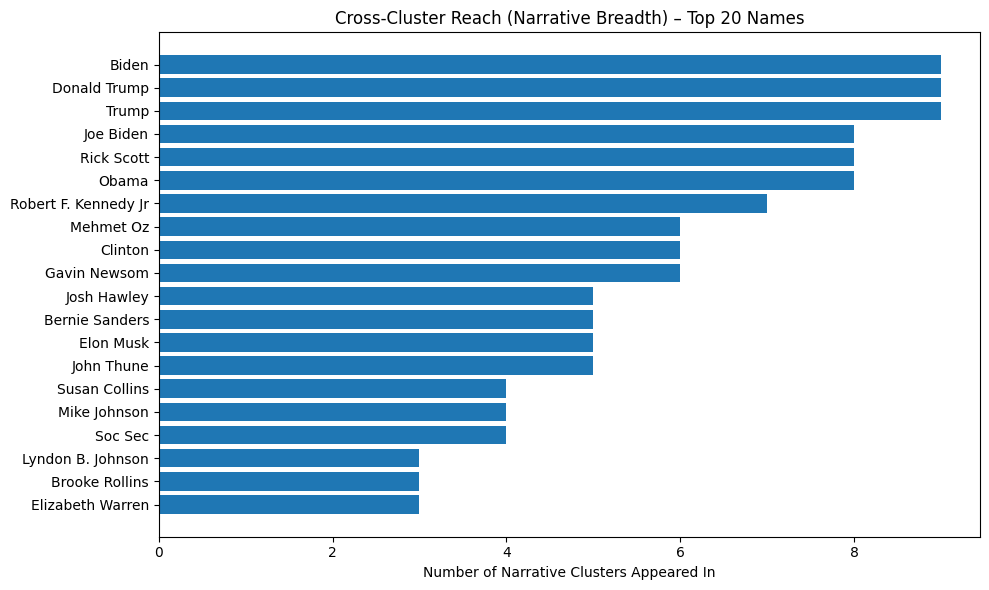

In [ ]:
#--------------PLOT NER TOP NAMES BREADTH FUNCTION BLOCK------------------------
df_top_NER = topk.copy() #copy topk dataframe

# Helper: plot Top-10 for a single cluster
def plot_top10_for_cluster(df_top_NER , cluster_id, metric="mentions", topk=10):
    d = df_top_NER[df_top_NER["cluster"] == cluster_id].copy()
    if d.empty:
        raise ValueError(f"No rows for cluster {cluster_id}")
    if metric not in d.columns:
        raise ValueError(f"Metric '{metric}' not in columns {list(d.columns)}")
    d = d.sort_values(metric, ascending=False).head(topk)
    # shorter labels (optional): keep to 30 chars
    labels = d["name"].astype(str).str.slice(0, 30)
    values = d[metric].values

    plt.figure(figsize=(10, 6))
    plt.barh(labels[::-1], values[::-1])  # horizontal, most at top
    plt.xlabel(metric.capitalize())
    plt.title(f"Top {topk} names – Cluster {cluster_id} (by {metric})")
    plt.tight_layout()
    plt.show()

breadth = (df_top_NER.groupby("name")["cluster"].nunique()
             .sort_values(ascending=False)
             .reset_index(name="num_clusters"))

breadth_top = breadth.head(20)

plt.figure(figsize=(10,6))
plt.barh(breadth_top["name"][::-1], breadth_top["num_clusters"][::-1])
plt.xlabel("Number of Narrative Clusters Appeared In")
plt.title("Cross-Cluster Reach (Narrative Breadth) – Top 20 Names")
plt.tight_layout()
plt.show()
#-------------------------------------------------------------------------------

***
***
# URL JOIN MODULE BLOCK
Finds high-confidence tweet→article matches using shared URLs and turns them into a standardized matches table.

Links tweets to articles that share the same URL, giving you evidence that a tweet is connected to specific media coverage.

  - Cleans and canonicalizes URLs from tweets and media (removes http/https, www, tracking params, trailing slashes) so different versions of the same link match.
  - Extracts the first URL from each tweet’s text, canonicalizes it, and canonicalizes each article’s article_url.
  - Joins tweets and articles by canonical URL to get exact-evidence matches (very high precision).
  - Filters pairs so the article appears within 0..WINDOW_DAYS after the tweet (tweet precedes coverage).
  - Maps matched doc_ids back to row indices in the unified corpus and builds url_matches, a clean table with:
    - tweet/author/cluster,
    - media outlet/time,
    - lead_days and similarity = 1.0.


In [ ]:
#------------------URL JOIN MODULE BLOCK----------------------------------------
# ---------------------------------------------
# URL JOIN (exact evidence)
# ---------------------------------------------

# Define URL handling + canonicalizer
# Normalizes different representations of the same URL so joins will match (e.g., removes http/https, www, tracking params like ?utm=…, and trailing /).
URL_RE = r"https?://\S+"
def canonicalize(url_series: pd.Series) -> pd.Series:
    s = url_series.astype(str)
    s = s.mask(s.str.strip().eq(""), np.nan)              # treat "" as NaN
    s = s.str.replace(r"https?://(www\.)?", "", regex=True)
    s = s.str.replace(r"[?#].*$", "", regex=True)
    s = s.str.rstrip("/")
    return s

# Tweets: extract & canonicalize first URL in the text
# Extract & canonicalize tweet URLs
# Pulls the first URL mentioned in each tweet’s text and cleans tail punctuation like ) or ,
t_urls = tweets_nf.copy()
t_urls["_url"] = (
    t_urls["_text"].str.extract(f"({URL_RE})", expand=False).str.replace(r"[),.]+$", "", regex=True)
)
t_urls["_url_canon"] = canonicalize(t_urls["_url"])

# Media: canonicalize article_url
m_urls = m.copy()
m_urls["_url_canon"] = canonicalize(m_urls["url"])

# Merge with explicit suffixes
# Join tweets to media by canonical URL
# Inner join: only tweet–article pairs that reference the same canonical URL survive.
# This yields high-precision matches (exact evidence vs. fuzzy text matches).
url_join = (
    t_urls.merge(
        m_urls[["_url_canon", "time", "doc_id", "outlet"]],
        on="_url_canon", how="inner", suffixes=("_tweet", "_media")
    )
)
# Timing filter (lead/lag logic)
# Keeps pairs where the article appears 0..WINDOW_DAYS after the tweet, aligning with the “tweet preceded coverage” assumption.
url_join["lead_days"] = (to_dt(url_join["time_media"]) - to_dt(url_join["time_tweet"])).dt.days
url_join = url_join[(url_join["lead_days"] >= 0) & (url_join["lead_days"] <= WINDOW_DAYS)].copy()

# Map back to corpus indices
# Allows convert matched doc_ids into row indices in corpus (so everything downstream lines up).
tweet_docid_to_idx = (
    corpus.loc[tweet_mask, ["doc_id"]].reset_index().set_index("doc_id")["index"]
)
media_docid_to_idx = (
    corpus.loc[media_mask, ["doc_id"]].reset_index().set_index("doc_id")["index"]
)

# Build a standardized matches table
# Produces a dataframe in the same schema used by text-similarity matches, and sets similarity = 1.0 to mark these as exact.
rows = []
for _, r in url_join.iterrows():
    tdoc = str(r["doc_id_tweet"]); mdoc = str(r["doc_id_media"])
    if tdoc in tweet_docid_to_idx and mdoc in media_docid_to_idx:
        ti = int(tweet_docid_to_idx[tdoc])
        mi = int(media_docid_to_idx[mdoc])
        rows.append({
            "tweet_row": ti,
            "tweet_author": corpus.at[ti, "author"],   # <- always from corpus
            "tweet_doc_id": tdoc,
            "tweet_time": r["time_tweet"],
            "tweet_cluster": int(corpus.at[ti, "cluster"]),
            "media_row": mi,
            "media_outlet": (r["outlet_media"] if pd.notna(r["outlet_media"]) and str(r["outlet_media"]).strip() else "unknown"),
            "media_doc_id": mdoc,
            "media_time": r["time_media"],
            "similarity": 1.0,
            "lead_days": int(r["lead_days"]),
        })

url_matches = pd.DataFrame(rows)
#-------------------------------------------------------------------------------

***
***
# EARLINESS BLOCK
Measures how early each document appears within its narrative cluster.

creates a within-narrative earliness metric used later to tell originators (early voices) from late amplifiers.

- First, it standardizes timestamps and, if a document is missing a time, it fills it with the latest time in its cluster (so missing dates don’t get “early” credit).
- Then it computes an early_pct score within each cluster, ranking documents by time and mapping them to a 0–1 scale:
  - early_pct ≈ 0 → very early in that narrative
  - early_pct ≈ 1 → very late in that narrative


In [ ]:
#----------------EARLINESS BLOCK------------------------------------------------
# ---------------------------------------------
# EARLINESS within each narrative
# ---------------------------------------------

# Standardize times & handle missing timestamps
# Converts all times to UTC datetimes.
# If a doc’s time is missing, it’s filled with the latest time in its own cluster, Effect: missing times are treated as latest (they won’t get “early” credit).
corpus["time"] = to_dt(corpus["time"])
corpus["time"] = corpus["time"].fillna(corpus.groupby("cluster")["time"].transform("max"))

# Define a 0–1 “earliness” scaler using ranks
# Ranks times within a group (earliest gets rank 1).
# Linearly rescales ranks to [0, 1]: (0.0 → earliest in the group)(1.0 → latest in the group)
def early_pct_transform(s: pd.Series) -> pd.Series:
    r = s.rank(method="min")
    return (r - r.min()) / (r.max() - r.min() + 1e-9)

# Compute earliness per cluster (Applies the scaler inside each narrative cluster.)
# earliness score compares documents only to others in the same narrative, not across unrelated topics.
corpus["early_pct"] = corpus.groupby("cluster", observed=True)["time"].transform(early_pct_transform)
#-------------------------------------------------------------------------------

***
***
# TWEET/MEDIA INDEX LISTS AND STREAMING SIMILARITIES (TURBO) BLOCK
Does the fast, large-scale tweet→article matching using text similarity, then merges that with the URL-based matches.

Links tweets to likely related articles based on semantic/lexical similarity within a time window, then combines that with URL matches to form the master matches table for cross-media influence.

- Splits the corpus into tweet vs media indices, gets their times and outlets.
- Pre-normalizes TF-IDF vectors (and embeddings if enabled) so cosine similarity becomes a dot product.
- For each tweet, finds media articles in a time window (e.g., within WINDOW_DAYS after the tweet).
- Within that window, computes:
  - TF-IDF cosine similarity, and optionally
  - A hybrid similarity (TF-IDF + embeddings, weighted by HYBRID_WT).

- Keeps only matches:
  - Above the similarity threshold (SIM_THR),
  - Up to TOPK_PER_TWEET per tweet, for speed.
- Builds text_matches with tweet/doc IDs, outlets, times, similarity, and lead_days.
- Safely unions these text-based matches with the earlier url_matches, deduping tweet–article pairs and tagging each as evidence = "url" (near-1 similarity) or "text".

In [ ]:
# --------TWEET/MEDIA INDEX LISTS AND STREAMING SIMILARITIES (TURBO) BLOCK -----
import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize as sk_normalize
import scipy.sparse as sp

# ---------- KNOBS (feel free to tweak) ----------
BATCH_TWEETS = 512  # tweets processed per outer batch
MAX_MEDIA_CAND_PER_TWEET = 800 # cap candidates after the date window (if slow, lower to 400)
OVERSAMPLE_TIME = 1.0  # 1.0 = strict window; >1 expands slightly
USE_EMBEDS = bool(USE_EMBEDDINGS_FOR_MATCH and (E is not None))
HYBRID_WT = float(HYBRID_EMBED_WT)

SIM_THR = float(SIM_THRESHOLD)   # from the config
TOPK_K = int(TOPK_PER_TWEET) if TOPK_PER_TWEET is not None else None
WIN_D = int(WINDOW_DAYS)

# ---------- Split & fetch ----------
tweet_mask = corpus["_kind"] == "tweet"
media_mask = corpus["_kind"] == "media"
t_idx = corpus.index[tweet_mask].to_numpy()
m_idx = corpus.index[media_mask].to_numpy()
if t_idx.size == 0 or m_idx.size == 0:
    raise ValueError("Need both tweet and media documents.")

# Times (numpy datetime64[ns, UTC])
t_times = pd.to_datetime(corpus.loc[t_idx, "time"], utc=True).to_numpy()
m_times = pd.to_datetime(corpus.loc[m_idx, "time"], utc=True).to_numpy()
m_outlets = (corpus.loc[m_idx, "outlet"].fillna("unknown")
             .replace({"": "unknown", "nan": "unknown"}).astype(str).to_numpy())

# ---------- Pre-normalize once: cosine -> dot ----------
# Ensure CSR and L2 normalization so dot = cosine
Xt_all = X_tfidf[t_idx].tocsr(copy=True)
Xm_all = X_tfidf[m_idx].tocsr(copy=True)
Xt_all = sk_normalize(Xt_all, norm="l2", copy=False)
Xm_all = sk_normalize(Xm_all, norm="l2", copy=False)

# Embeddings (optional)
if USE_EMBEDS:
    Et_all = E[t_idx].astype("float32", copy=False)
    Em_all = E[m_idx].astype("float32", copy=False)
    Et_all /= (np.linalg.norm(Et_all, axis=1, keepdims=True) + 1e-12)
    Em_all /= (np.linalg.norm(Em_all, axis=1, keepdims=True) + 1e-12)
else:
    Et_all = Em_all = None

# ---------- Sort media by time once ----------
m_order = np.argsort(m_times)
m_times_sorted = m_times[m_order]
Xm_sorted = Xm_all[m_order]
Em_sorted = Em_all[m_order] if USE_EMBEDS else None
m_out_sorted = m_outlets[m_order]
m_idx_sorted = m_idx[m_order]  # map back to corpus rows

def _media_window_bounds(t_time, days=7, oversample=1.0):
    """Return [L, R) indices into the *sorted* media arrays for the time window."""
    if pd.isna(t_time):
        return 0, 0
    end_time = t_time + np.timedelta64(int(days * oversample), 'D')
    L = np.searchsorted(m_times_sorted, t_time, side="left")
    R = np.searchsorted(m_times_sorted, end_time, side="right")
    return L, R

rows = []
rng = np.random.RandomState(42)
n_t = len(t_idx)

for start in range(0, n_t, BATCH_TWEETS):
    end = min(start + BATCH_TWEETS, n_t)
    for i_local in range(start, end):
        gi_t = t_idx[i_local]
        t_time = t_times[i_local]
        if pd.isna(t_time):
            continue

        L, R = _media_window_bounds(t_time, days=WIN_D, oversample=OVERSAMPLE_TIME)
        k = R - L
        if k <= 0:
            continue

        # Cap candidate set for speed
        if k > MAX_MEDIA_CAND_PER_TWEET:
            take = rng.choice(k, size=MAX_MEDIA_CAND_PER_TWEET, replace=False)
            Ls = np.sort(L + take)  # sorted indices into media arrays
        else:
            Ls = np.arange(L, R, dtype=int)

        # TF-IDF cosine (as sparse dot on L2-normalized rows)
        x_row = Xt_all[i_local] # 1 x d (CSR)
        X_blk = Xm_sorted[Ls] # k' x d (CSR)
        sim_t = x_row.dot(X_blk.T).toarray().ravel()

        # Optional embedding cosine
        if USE_EMBEDS:
            e_row = Et_all[i_local:i_local+1]  # (1 x d_e)
            e_blk = Em_sorted[Ls] # (k' x d_e)
            sim_e = (e_row @ e_blk.T).ravel()
            sim = (1 - HYBRID_WT) * sim_t + HYBRID_WT * sim_e
        else:
            sim = sim_t

        # Threshold, then top-K
        on = np.where(sim >= SIM_THR)[0]
        if on.size == 0:
            continue

        if TOPK_K is not None and on.size > TOPK_K:
            part = np.argpartition(sim[on], -TOPK_K)[-TOPK_K:]
            keep = on[part]
            keep = keep[np.argsort(-sim[keep])]  # sort descending
        else:
            keep = on[np.argsort(-sim[on])]

        for j in keep:
            ms = Ls[j]
            gi_m = int(m_idx_sorted[ms])
            rows.append({
                "tweet_row": int(gi_t),
                "tweet_author": corpus.at[gi_t, "author"],
                "tweet_doc_id": corpus.at[gi_t, "doc_id"],
                "tweet_time": pd.Timestamp(t_time),
                "tweet_cluster": int(corpus.at[gi_t, "cluster"]),
                "media_row": gi_m,
                "media_outlet": m_out_sorted[ms],
                "media_doc_id": corpus.at[gi_m, "doc_id"],
                "media_time": pd.Timestamp(m_times_sorted[ms]),
                "similarity": float(sim[j]),
                "lead_days": int((m_times_sorted[ms] - t_time) / np.timedelta64(1, 'D')),
            })

text_matches = pd.DataFrame(rows)

# --Safe union with URL matches (works whether you ran URL JOIN or not) --
EXPECTED_MATCH_COLS = [
    "tweet_row","tweet_author","tweet_doc_id","tweet_time","tweet_cluster",
    "media_row","media_outlet","media_doc_id","media_time","similarity","lead_days"
]

if "url_matches" not in globals():
    url_matches = pd.DataFrame(columns=EXPECTED_MATCH_COLS)

frames = [df for df in [text_matches, url_matches] if not df.empty]
matches = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=EXPECTED_MATCH_COLS)
matches = matches.drop_duplicates(subset=["tweet_doc_id","media_doc_id"])
matches["evidence"] = np.where(matches["similarity"] >= 0.9999, "url", "text")
# ------------------------------------------------------------------------------

***
***
# PER-TWEET AGG + HIT FLAGS BLOCK
Summarizes cross-media impact for each tweet and sets “hit” flags used later in the leaderboards.

Turns the raw tweet→article matches into per-tweet impact metrics and binary “this tweet broke out” indicators.

- Initializes per-document fields in corpus:
  - hits_outlets – how many distinct outlets picked up that tweet.
  - lead_days_min – fastest tweet→media lag in days.
  - cross_media_hit – 1 if outlets ≥ MIN_OUTLETS_STD.
  - cross_media_hit_strict – 1 if outlets ≥ MIN_OUTLETS_STRICT.
- If there are matches, it groups them by tweet_row, computes distinct outlets and min lead time, and writes those values plus the hit flags back onto the tweet rows.

In [ ]:
#----------------PER-TWEET AGG + HIT FLAGS BLOCK--------------------------------
# ---------------------------------------------
# PER-TWEET AGG + HIT FLAGS
# ---------------------------------------------
corpus["hits_outlets"] = pd.Series(0, index=corpus.index, dtype="Int64") #  # how many distinct outlets matched this tweet
corpus["lead_days_min"] = pd.Series(pd.NA, index=corpus.index, dtype="Int64") # fastest (smallest) tweet→media lag in days
corpus["cross_media_hit"] = pd.Series(0, index=corpus.index, dtype="Int64") #  # standard hit flag (>= MIN_OUTLETS_STD)
corpus["cross_media_hit_strict"] = pd.Series(0, index=corpus.index, dtype="Int64") # strict hit flag (>= MIN_OUTLETS_STRICT)

# Aggregate matches at the tweet level
if not matches.empty:
    per_tweet = (
        matches.groupby("tweet_row")
        .agg(distinct_outlets=("media_outlet","nunique"),
             lead_days_min=("lead_days","min"))
        .astype({"distinct_outlets":"Int64","lead_days_min":"Int64"})
    )
    # Write the aggregates back onto the right tweet rows AND Compute hit flags using the thresholds
    corpus.loc[per_tweet.index, "hits_outlets"] = per_tweet["distinct_outlets"].values
    corpus.loc[per_tweet.index, "lead_days_min"] = per_tweet["lead_days_min"].values
    corpus.loc[per_tweet.index, "cross_media_hit"] = (per_tweet["distinct_outlets"] >= MIN_OUTLETS_STD).astype("Int64").values
    corpus.loc[per_tweet.index, "cross_media_hit_strict"] = (per_tweet["distinct_outlets"] >= MIN_OUTLETS_STRICT).astype("Int64").values
#-------------------------------------------------------------------------------

***
***
# LEADERBOARD + INFLUENCE SCORE BLOCK
Builds the influencer leaderboards and computes each author’s InfluenceScore + role (Originator vs Amplifier).

Turns all the per-tweet metrics into ranked influencer tables with an interpretable InfluenceScore and role label for each author.

- Defines helper reducers to safely compute means/medians even if data are messy.

- build_leaderboard(...):
  - Filters to tweets and sanitizes fields (earliness, hits, lead days, hit flag).
  - Adds a time-decay weight so recent tweets count more (≈30-day half-life).
  - Aggregates per author: number of tweets, cross-media hits, average earliness, typical outlets reached, pickup speed, engagement, and recency.
  - Builds normalized components (Z_hit, Z_early, Z_speed, Z_outlets, Z_engage, Z_time) and combines them into an InfluenceScore with explicit weights.
  - Classifies each author as Originator, Amplifier, or Mixed/Low based on hit rate + earliness + speed.
  - Applies a minimum tweet count and ranks authors by InfluenceScore.
- Creates two leaderboards:
  - leaderboard_std – standard hit definition.
  - leaderboard_strict – stricter “broke out across outlets” definition.
- add_explain(...) adds a human-readable “why_ranked” explanation string for each author (hits, hit rate, how early, median lead days).

In [ ]:
#--------------LEADERBOARD + INFLUENCE SCORE BLOCK------------------------------
# ---------------------------------------------
# LEADERBOARDS + INFLUENCE SCORE (with time-decay fix)
# ---------------------------------------------

# Helper reducers _gmean and _gmedian
# Coerce to numeric, drop NaNs, then compute mean/median. Prevents crashes from stringy or missing values.
def _gmean(x):
    s = pd.to_numeric(x, errors="coerce").dropna()
    return s.mean() if len(s) else np.nan

def _gmedian(x):
    s = pd.to_numeric(x, errors="coerce").dropna()
    return s.median() if len(s) else np.nan

# Filter tweets + sanitize fields
# Ensures inputs are numeric and defined.
def build_leaderboard(corpus: pd.DataFrame, hit_col: str, min_tweets: int = 3) -> pd.DataFrame:
    tw = corpus.loc[corpus["_kind"] == "tweet"].copy()
    tw["early_pct"] = pd.to_numeric(tw["early_pct"], errors="coerce").fillna(1.0)
    tw["hits_outlets"] = pd.to_numeric(tw["hits_outlets"], errors="coerce").fillna(0)
    tw["lead_days_min"]= pd.to_numeric(tw["lead_days_min"], errors="coerce")
    tw[hit_col] = pd.to_numeric(tw[hit_col], errors="coerce").fillna(0)

    # time decay (UTC) — robust
    # Recent tweets count more (≈30-day half-life). Using now(tz="UTC") + to_dt avoids tz errors and negative ages.
    now = pd.Timestamp.now(tz="UTC")
    t_when = to_dt(tw["time"])
    age_days = (now - t_when).dt.total_seconds() / 86400.0
    age_days = age_days.clip(lower=0).fillna(0)
    tw["time_weight"] = np.exp(-(age_days / 30.0))  # ~30-day half-life

    # Aggregate per author (Produces author-level stats: volume, hits, typical earliness, outlets reached, pickup speed, engagement, and recency.)
    lb = (
        tw.groupby("author", dropna=False)
        .agg(
            tweets=("author","size"),
            cross_media_hits=(hit_col,"sum"),
            earliness_mean=("early_pct", _gmean),
            outlets_median=("hits_outlets", _gmedian),
            lead_days_min_median=("lead_days_min", _gmedian),
            engagement_mean=("engagement", _gmean),
            time_weight=("time_weight","mean")
        ).reset_index()
    )

    lb["hit_rate"] = (lb["cross_media_hits"] / lb["tweets"]).fillna(0)

    # Normalized components
    # Derived and normalized features (Everything is mapped to 0–1 so different signals can be combined.)
    lb["Z_hit"] = lb["hit_rate"].clip(0,1)
    lb["Z_early"] = (1 - lb["earliness_mean"]).clip(0,1)
    lb["Z_speed"] = (1 - (lb["lead_days_min_median"].clip(0,7)/7)).fillna(0)
    lb["Z_outlets"] = (lb["outlets_median"].clip(0,3)/3).fillna(0)
    lb["Z_engage"] = lb["engagement_mean"].rank(pct=True, na_option="bottom")
    lb["Z_time"] = lb["time_weight"].rank(pct=True, na_option="bottom")

    # InfluenceScore (weighted blend) Emphasizes hit rate and earliness, then speed and outlet breadth, with lighter weights for engagement and recency.
    W = {"hit":0.35, "early":0.20, "speed":0.15, "outlets":0.15, "engage":0.10, "time":0.05}
    lb["InfluenceScore"] = (
        W["hit"]*lb["Z_hit"] + W["early"]*lb["Z_early"] + W["speed"]*lb["Z_speed"] +
        W["outlets"]*lb["Z_outlets"] + W["engage"]*lb["Z_engage"] + W["time"]*lb["Z_time"]
    )

    # Role classification Originators: reliably early with solid pickup; Amplifiers: get pickup but tend to be later; others: mixed/low signal.
    def classify_role(r):
        cond_origin = (r["Z_hit"]>=0.5) and (r["Z_early"]>=0.67) and (r["Z_speed"]>=0.6)
        cond_ampl   = (r["Z_hit"]>=0.5) and (r["Z_early"]<0.5)
        if cond_origin: return "Originator"
        if cond_ampl:   return "Amplifier"
        return "Mixed/Low"
    # Eligibility, sorting, ranking
    # Requires a minimum tweet count (default 3), then orders by influence and adds a 1-based rank.
    lb = lb.query("tweets >= @min_tweets").copy()
    lb["role"] = lb.apply(classify_role, axis=1)
    lb = lb.sort_values("InfluenceScore", ascending=False).reset_index(drop=True)
    lb.insert(0, "rank", range(1, len(lb)+1))
    return lb
# Two leaderboards (both a broad and a conservative view.)
# Standard: a hit if ≥ MIN_OUTLETS_STD outlets (default 1).
# Strict: a hit if ≥ MIN_OUTLETS_STRICT outlets (default 2).
leaderboard_std    = build_leaderboard(corpus, "cross_media_hit", MIN_TWEETS)
leaderboard_strict = build_leaderboard(corpus, "cross_media_hit_strict", MIN_TWEETS)

# Human-readable “why” column (Concise textual rationale per author for audits and UI tooltips.)
def add_explain(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    d["why_ranked"] = (
        "hits=" + d["cross_media_hits"].fillna(0).astype(int).astype(str) +
        ", hit_rate=" + (d["hit_rate"]*100).round(0).fillna(0).astype(int).astype(str) + "%" +
        ", early=" + (d["earliness_mean"]*100).round(0).fillna(0).astype(int).astype(str) + "%" +
        ", lead_med=" + d["lead_days_min_median"].round(0).fillna(-1).astype(int).astype(str).replace({"-1":"—"})
    )
    return d

leaderboard_std = add_explain(leaderboard_std)
leaderboard_strict = add_explain(leaderboard_strict)
#-------------------------------------------------------------------------------

***
***
# INFLUENCER CLUSTERS BLOCK
Groups influencers into higher-level “types” based on which narratives they talk about.

Clusters authors by their narrative portfolios to reveal influencer archetypes.

- Takes only tweet rows and keeps author + their assigned cluster (narrative).
- Builds an author × narrative matrix: how many tweets each author has in each narrative.
- Normalizes each row to proportions, so it reflects the mix of narratives per author, not raw volume.
- Chooses a reasonable number of influencer clusters (k_inf) based on how many authors there are (capped by K_INF_MAX).
- Runs K-Means on those narrative-mix vectors to cluster authors with similar portfolios.
- Outputs influencer_clusters, a table where each author is assigned an inf_cluster (e.g., “Policy wonks”, “Culture commentators”, etc., once you label them).

In [ ]:
#-------------INFLUENCER CLUSTERS BLOCK-----------------------------------------
# ---------------------------------------------
# INFLUENCER CLUSTERS (author × narrative mix)
# ---------------------------------------------

# Select tweet rows & keep just author/cluster
# Uses only tweets (not media).
# Needs each tweet’s assigned narrative cluster from the earlier K-Means.
tw = corpus.loc[corpus["_kind"]=="tweet", ["author","cluster"]].dropna()

# Build an author × narrative frequency table
# Rows = authors, columns = narrative clusters, values = # of tweets the author made in each narrative.
# Example row: {"Cluster0": 12, "Cluster1": 0, "Cluster2": 5, ...}.
auth_narr = (tw.groupby(["author","cluster"]).size().unstack(fill_value=0))

# Normalize per author (turn counts into proportions)
# Each row now sums to ~1.0 → a portfolio of narratives per author.
# This prevents prolific authors from dominating due to sheer volume; we care about mix, not count.
auth_narr_norm = auth_narr.div(auth_narr.sum(axis=1), axis=0).fillna(0)

# Pick number of influencer clusters (k)
# Heuristic: about 1 cluster per ~20 authors, but:never below 2,and capped by K_INF_MAX (default 10) for interpretability and stability.
# Note: this k is independent of the earlier narrative K (auto-K for narratives doesn’t change this cap).
k_inf = max(2, min(K_INF_MAX, max(2, auth_narr_norm.shape[0]//20)))

# Cluster authors by their narrative portfolios
# K-Means on the proportion vectors groups authors with similar narrative mixes.
# n_init=20 makes the result more stable; fixed seed for reproducibility.
km_inf = KMeans(n_clusters=k_inf, n_init=20, random_state=42)
inf_labels = km_inf.fit_predict(auth_narr_norm.values)

# Return a labeled table
# Adds inf_cluster to each author’s proportion row.
# Can now profile clusters (e.g., top narratives per cluster, sample authors) and name them (“Policy Hawks,” “Culture Commentators,” etc.).
influencer_clusters = auth_narr_norm.assign(inf_cluster=inf_labels).reset_index()
#-------------------------------------------------------------------------------


***
***
# BETTER TOP TERMS MODULE BLOCK
Extracts clean, human-readable “topic labels” for each narrative cluster using TF-IDF.

- For each cluster, it:
  - Averages the TF-IDF vectors to see which terms are most characteristic.
  - Ranks terms by importance.
  - Filters out junk (all digits, custom stopwords, ultra-short throwaway tokens).
  - Prefers bigrams first (e.g., “social security”, “border policy”) and then fills in with unigrams, avoiding duplicates.

Returns narr_top_terms, a Series mapping each cluster → list of ~12 top phrases you can use to name/describe the narrative in dashboards and reports.

In [ ]:
# -----------BETTER TOP TERMS MODULE BLOCK--------------------------------------
# =========================================================
# Better top-terms (favor bigrams, remove dupes/junk)
# =========================================================


def top_terms_by_cluster(X_tfidf, labels, feature_names, topk=12):
    labels = np.asarray(labels)
    out = {}
    for c in np.sort(pd.unique(labels)):
        mask = (labels == c)
        if mask.sum() == 0:
            out[c] = []
            continue
        mean_vec = X_tfidf[mask].mean(axis=0).A1
        idx = np.argsort(mean_vec)[::-1]
        cand = [feature_names[i] for i in idx]
        # Filter obvious junk (Removes numeric tokens, stopwords, and ultra-short unigrams that tend to be noise.)
        def keep_term(t):
            if all(ch.isdigit() for ch in t): return False
            if t in CUSTOM_STOPS: return False
            if len(t) < 3 and " " not in t: return False
            return True

        cand = [t for t in cand if keep_term(t)]
        # Prefer bigrams, then fill with unigrams (de-dup aware)
        # First, pick the strongest bigrams (e.g., “social security”, “border policy”)—these are more descriptive than single words.
        # Track the unigrams that appear inside chosen bigrams in seen_unigrams.
        bigrams = [t for t in cand if " " in t]
        chosen, seen_unigrams = [], set()
        for t in bigrams:
            if len(chosen) >= topk: break
            chosen.append(t)
            for u in t.split():
                seen_unigrams.add(u)

        if len(chosen) < topk:
            unigrams = [t for t in cand if " " not in t and t not in seen_unigrams]
            for t in unigrams:
                if len(chosen) >= topk: break
                chosen.append(t)
        out[c] = chosen[:topk]
    return pd.Series(out, name="top_terms") # Return labels (Produces a Series mapping cluster_id → [top terms], used to label or annotate clusters in reports/dashboards.)

narr_top_terms = top_terms_by_cluster(X_tfidf, corpus["cluster"].values, feature_names, topk=12)
#-------------------------------------------------------------------------------

***
***
# NAARRATIVE PROPAGATION ANALYSIS BLOCK
Powers the “narrative propagation” and diffusion analysis parts of the tool — how narratives move over time and between actors/outlets.

Turns the corpus + matches into time-series and network views that let you analyze how narratives spread over time and through whom (authors, outlets, URLs).

1.Time + matches sanitation:
  - _to_utc, _canonicalize_urls, coerce_matches_for_propagation(...)
Make sure all times are clean, timezone-consistent (UTC) and that the matches table has the right columns in a standard format.

2.Narrative time-series + surge detection:
  - build_narrative_timeseries(...):
  - Builds a daily (or weekly) time series per cluster of tweet and media counts.
  - Joins in match-based metrics like lead_share (how often tweets lead media) and n_matches.
  - Adds spike flags using rolling z-scores and optional change-point flags via ruptures to mark structural shifts in attention.
  - Indicates when each narrative heats up, cools down, and where surges occur.

3.Author–outlet diffusion graph:
- build_author_outlet_graph(...):
  - From matches, builds a directed graph from author X → outlet Y.
  - Computes basic centrality (in-degree, out-degree, optional betweenness).
  - Returns edge list + centrality table so you can see which authors and outlets are central in the cross-media flow.
  - Indicates who tends to feed which outlets, and which nodes are structurally important.

4.URL diffusion graph:
- build_url_diffusion_graph(...):
  - Creates a graph of url → author and url → outlet.
  - Again computes centrality metrics for URLs, authors, and outlets.
  - reveals: which URLs act as hubs and how they spread from tweets into media coverage.

In [ ]:
#------------NAARRATIVE PROPAGATION ANALYSIS BLOCK------------------------------
from typing import Optional, Tuple
# --- robust UTC coercion (safe for naive/tz-aware) ---
def _to_utc(s: pd.Series) -> pd.Series:
    # Handles both naive and tz-aware inputs; always returns tz-aware UTC
    return pd.to_datetime(s, errors="coerce", utc=True)

def _canonicalize_urls(s: pd.Series) -> pd.Series:
    s = s.fillna("").astype(str)
    s = s.str.replace(r"https?://(www\.)?", "", regex=True)
    s = s.str.replace(r"[?#].*$", "", regex=True)
    return s.str.rstrip("/")

# make matches columns consistent & tz-aware ---
def coerce_matches_for_propagation(matches: pd.DataFrame) -> pd.DataFrame:
    df = matches.copy()

    # Ensure canonical names EXIST (tweet_time, media_time)
    if "tweet_time" not in df.columns and "time_tweet" in df.columns:
        df["tweet_time"] = df["time_tweet"]
    if "media_time" not in df.columns and "time_media" in df.columns:
        df["media_time"] = df["time_media"]

    # Provide reverse aliases too (time_tweet/time_media)
    if "time_tweet" not in df.columns and "tweet_time" in df.columns:
        df["time_tweet"] = df["tweet_time"]
    if "time_media" not in df.columns and "media_time" in df.columns:
        df["time_media"] = df["media_time"]

    # Ensure required columns exist
    needed = ["tweet_author","media_outlet","tweet_cluster","lead_days",
              "tweet_time","media_time","time_tweet","time_media"]
    for col in needed:
        if col not in df.columns:
            df[col] = pd.NA

    # Force datetimes to UTC
    df["tweet_time"] = _to_utc(df["tweet_time"])
    df["media_time"] = _to_utc(df["media_time"])
    df["time_tweet"] = _to_utc(df["time_tweet"])
    df["time_media"] = _to_utc(df["time_media"])

    keep = ["tweet_author","media_outlet","tweet_cluster","lead_days",
            "tweet_time","media_time","time_tweet","time_media"]
    return df[keep].copy()

def build_narrative_timeseries(
    corpus: pd.DataFrame,
    matches_u: pd.DataFrame,
    freq: str = TS_FREQ,
    roll_days: int = ROLL_DAYS,
    z_thresh: float = Z_THRESH,
    use_changepoints: bool = USE_CHANGEPOINTS
) -> pd.DataFrame:
    df = corpus.copy()
    df["time"] = _to_utc(df["time"])
    df["date"] = df["time"].dt.floor(freq)

    by_kind = (
        df.groupby(["cluster","date","_kind"]).size()
          .unstack(fill_value=0).reset_index()
          .rename(columns={"tweet":"tweets","media":"media"})
    )
    if "tweets" not in by_kind.columns: by_kind["tweets"] = 0
    if "media"  not in by_kind.columns: by_kind["media"]  = 0

    mm = matches_u.copy()
    # tolerate either name (tweet_time/time_tweet, media_time/time_media)
    mm["media_time"] = _to_utc(mm["media_time"] if "media_time" in mm.columns else mm.get("time_media"))
    mm["tweet_time"] = _to_utc(mm["tweet_time"] if "tweet_time" in mm.columns else mm.get("time_tweet"))

    if mm["media_time"].isna().all():
        lead = by_kind[["cluster","date"]].copy()
        lead["lead_share"] = 0.0
        lead["n_matches"] = 0
    else:
        mm["date"] = mm["media_time"].dt.floor(freq)
        mm["tweet_first"] = (mm["lead_days"] >= 0).astype(int)
        lead = (
            mm.groupby(["tweet_cluster","date"])["tweet_first"]
              .agg(["mean","size"]).reset_index()
              .rename(columns={"tweet_cluster":"cluster","mean":"lead_share","size":"n_matches"})
        )

    ts = (
        by_kind.merge(lead, on=["cluster","date"], how="left")
               .fillna({"lead_share":0.0, "n_matches":0})
               .sort_values(["cluster","date"])
               .reset_index(drop=True)
    )

    # Surge detection (rolling z + optional change-points)
    def add_spikes_and_cps(g):
        g = g.sort_values("date").copy()
        g["media_roll_mean"] = g["media"].rolling(roll_days, min_periods=3).mean()
        g["media_roll_std"]  = g["media"].rolling(roll_days, min_periods=3).std(ddof=0)
        g["media_z"] = (g["media"] - g["media_roll_mean"]) / (g["media_roll_std"].replace(0, np.nan))
        g["spike_flag"] = (g["media_z"] >= z_thresh).astype(int)

        if use_changepoints and HAS_RUPTURES and len(g) >= max(roll_days, 20):
            y = g["media"].fillna(0).to_numpy()
            try:
                algo = rpt.Pelt(model=CP_MODEL).fit(y)
                cps = algo.predict(pen=CP_PENALTY)
                g["changepoint_flag"] = 0
                for cp in cps:
                    idx = min(cp-1, len(g)-1)
                    g.iloc[idx, g.columns.get_loc("changepoint_flag")] = 1
            except Exception:
                g["changepoint_flag"] = 0
        else:
            g["changepoint_flag"] = 0
        return g

    ts = ts.groupby("cluster", group_keys=False).apply(add_spikes_and_cps)
    return ts

def build_author_outlet_graph(matches_u: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    for _, r in matches_u.iterrows():
        a = f"author::{str(r['tweet_author']) if pd.notna(r['tweet_author']) else 'unknown'}"
        o = f"outlet::{str(r['media_outlet']) if pd.notna(r['media_outlet']) else 'unknown'}"
        rows.append({
            "src": a,
            "dst": o,
            "cluster": int(r["tweet_cluster"]) if pd.notna(r["tweet_cluster"]) else -1,
            "lead_days": int(r["lead_days"]) if pd.notna(r["lead_days"]) else None,
            # accept either column name for times
            "time_tweet": r["tweet_time"] if "tweet_time" in matches_u.columns else r.get("time_tweet"),
            "time_media": r["media_time"] if "media_time" in matches_u.columns else r.get("time_media"),
        })
    edges = pd.DataFrame(rows)

    G = nx.DiGraph()
    G.add_edges_from([(r["src"], r["dst"]) for _, r in edges.iterrows()])

    in_deg  = dict(G.in_degree())
    out_deg = dict(G.out_degree())
    if COMPUTE_BETWEENNESS and len(G) > 0:
        bet = nx.betweenness_centrality(G, k=min(250, len(G)), seed=42)
    else:
        bet = {}

    cent = []
    for n in G.nodes():
        cent.append({
            "node": n,
            "type": "author" if n.startswith("author::") else "outlet",
            "in_degree": in_deg.get(n, 0),
            "out_degree": out_deg.get(n, 0),
            "betweenness": bet.get(n, 0.0)
        })
    centrality = pd.DataFrame(cent).sort_values(["type","in_degree","out_degree","betweenness"], ascending=False)
    return edges, centrality

def build_url_diffusion_graph(corpus: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    tw = corpus.loc[corpus["_kind"]=="tweet", ["author","time","_text"]].copy()
    md = corpus.loc[corpus["_kind"]=="media", ["outlet","time","url"]].copy()

    url_re = r"https?://\S+"
    tw["url"] = tw["_text"].str.extract(f"({url_re})", expand=False).str.replace(r"[),.]+$", "", regex=True)
    tw["url_canon"] = _canonicalize_urls(tw["url"])
    md["url_canon"] = _canonicalize_urls(md["url"])

    # Ensure times are UTC
    tw["time"] = _to_utc(tw["time"])
    md["time"] = _to_utc(md["time"])

    rows = []
    # URL -> author (tweet)
    for _, r in tw.dropna(subset=["url_canon"]).iterrows():
        if not r["url_canon"]: continue
        rows.append({"src": f"url::{r['url_canon']}", "dst": f"author::{r['author']}", "time": r["time"], "kind":"tweet"})
    # URL -> outlet (media)
    for _, r in md.dropna(subset=["url_canon"]).iterrows():
        if not r["url_canon"]: continue
        rows.append({"src": f"url::{r['url_canon']}", "dst": f"outlet::{r['outlet']}", "time": r["time"], "kind":"media"})

    edges = pd.DataFrame(rows)
    G = nx.DiGraph()
    G.add_edges_from([(r["src"], r["dst"]) for _, r in edges.iterrows()])

    in_deg  = dict(G.in_degree())
    out_deg = dict(G.out_degree())
    if COMPUTE_BETWEENNESS and len(G) > 0:
        bet = nx.betweenness_centrality(G, k=min(250, len(G)), seed=42)
    else:
        bet = {}

    cent = []
    for n in G.nodes():
        cent.append({
            "node": n,
            "type": ("url" if n.startswith("url::") else ("author" if n.startswith("author::") else "outlet")),
            "in_degree": in_deg.get(n, 0),
            "out_degree": out_deg.get(n, 0),
            "betweenness": bet.get(n, 0.0)
        })
    centrality = pd.DataFrame(cent).sort_values(["type","in_degree","out_degree","betweenness"], ascending=False)
    return edges, centrality
  #-----------------------------------------------------------------------------

***
***
# RUN PROPAGATION AND SAVE BLOCK
Runs the narrative propagation analysis and saves all the key outputs to disk.

Executes the propagation and diffusion modules and persists their outputs for use in dashboards, plots, or reports.

First it standardizes the matches (matches_u) and then:
- Builds the narrative time series ts (tweets/media per cluster over time + spikes/change-points).
- Builds the author→outlet diffusion graph (ao_edges, ao_cent).
- Builds the URL diffusion graph (url_edges, url_cent).

Then it writes everything out as CSVs into out_dir:
- narrative_timeseries.csv
- propagation_edges_author_to_outlet.csv
- centrality_author_to_outlet.csv
- url_diffusion_edges.csv
- centrality_url_graph.csv


In [ ]:
# ---------- RUN PROPAGATION AND SAVE BLOCK-------------------------------------
matches_u = coerce_matches_for_propagation(matches)
ts = build_narrative_timeseries(
    corpus, matches_u, freq=TS_FREQ, roll_days=ROLL_DAYS, z_thresh=Z_THRESH, use_changepoints=USE_CHANGEPOINTS
)

ao_edges, ao_cent = build_author_outlet_graph(matches_u)
url_edges, url_cent = build_url_diffusion_graph(corpus)

ts_path = out_dir / "narrative_timeseries.csv"
edges_ao_path = out_dir / "propagation_edges_author_to_outlet.csv"
cent_ao_path  = out_dir / "centrality_author_to_outlet.csv"
edges_url_path= out_dir / "url_diffusion_edges.csv"
cent_url_path = out_dir / "centrality_url_graph.csv"

ts.to_csv(ts_path, index=False)
ao_edges.to_csv(edges_ao_path, index=False)
ao_cent.to_csv(cent_ao_path, index=False)
url_edges.to_csv(edges_url_path, index=False)
url_cent.to_csv(cent_url_path, index=False)

print("\nNarrative propagation artifacts:")
print(" -", ts_path.resolve())
print(" -", edges_ao_path.resolve())
print(" -", cent_ao_path.resolve())
print(" -", edges_url_path.resolve())
print(" -", cent_url_path.resolve())

#-------------------------------------------------------------------------------

/tmp/ipython-input-4141045331.py:115: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ts = ts.groupby("cluster", group_keys=False).apply(add_spikes_and_cps)



Narrative propagation artifacts:
 - /content/output/narrative_timeseries.csv
 - /content/output/propagation_edges_author_to_outlet.csv
 - /content/output/centrality_author_to_outlet.csv
 - /content/output/url_diffusion_edges.csv
 - /content/output/centrality_url_graph.csv


***
***
# Propagation artifacts analysis + plotting environment

Pulls the propagation data back into memory and configures plotting so you can visualize narratives, author→outlet edges, and URL diffusion.

- Imports pandas, numpy, matplotlib, networkx, and Path.
- Loads the CSV outputs from the earlier propagation step:
  - narrative_timeseries.csv → ts
  - propagation_edges_author_to_outlet.csv → ao_edges
  - url_diffusion_edges.csv → url_edges
- Defines a tiny helper ensure_dir to create directories before saving plots.
- Sets a default matplotlib figure size.

In [ ]:
#-------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

# Load artifacts
ts = pd.read_csv("output/narrative_timeseries.csv", parse_dates=["date"])
ao_edges = pd.read_csv("output/propagation_edges_author_to_outlet.csv", parse_dates=["time_tweet","time_media"])
url_edges = pd.read_csv("output/url_diffusion_edges.csv", parse_dates=["time"])

# Small helpers
def ensure_dir(p): Path(p).parent.mkdir(parents=True, exist_ok=True)
plt.rcParams["figure.figsize"] = (10, 5)  # default size
#-------------------------------------------------------------------------------

***
***
# SAVE CORE OUTPUTS MODULE
Writes all the key results of the tool out to CSV so they can be used in dashboards, reports, or future runs.

- Influencer leaderboards (with roles + explanations):
  - leaderboard_standard_with_roles.csv
  - leaderboard_strict_with_roles.csv
- Tweet→media match table: tweet_media_matches.csv
-Full enriched corpus (with hits, clusters, etc.): corpus_with_hits_non_media.csv
- Influencer archetype clusters: influencer_clusters.csv
- Top narrative terms per cluster: narrative_top_terms.csv

In [ ]:
#----------------SAVE CORE OUTPUTS MODULE---------------------------------------
# ---------------------------------------------
# SAVE CORE OUTPUTS
# ---------------------------------------------
lb_std_path  = out_dir / "leaderboard_standard_with_roles.csv"
lb_strict_path = out_dir / "leaderboard_strict_with_roles.csv"
matches_path = out_dir / "tweet_media_matches.csv"
corpus_path  = out_dir / "corpus_with_hits_non_media.csv"
infclust_path = out_dir / "influencer_clusters.csv"
narrterms_path = out_dir / "narrative_top_terms.csv"

leaderboard_std.to_csv(lb_std_path, index=False)
leaderboard_strict.to_csv(lb_strict_path, index=False)
matches.to_csv(matches_path, index=False)
corpus.to_csv(corpus_path, index=False)
influencer_clusters.to_csv(infclust_path, index=False)
narr_top_terms.to_frame().to_csv(narrterms_path, index=False)
#-------------------------------------------------------------------------------

***
***
# Standard Leaderboard
Identify the individuals who most effectively shape narrative flow from Twitter/X into traditional media.

Purpose(Standard): Broad, inclusive view of influence. Captures any cross-media pickup.

A tweet counts as a “hit” if ≥ 1 media outlet covers or echoes it within the allowable lead window. (Adjustable by user in dashboard with knob 'MIN_OUTLETS_STD')


Basic Author / Activity Columns:
- rank: Final position on the leaderboard (1 = most influential).
- author: Twitter/X handle or name.
- tweets: Number of tweets by this author in the filtered period.

Cross-Media Impact Columns:
- cross_media_hits: Number of tweets that resulted in at least the required number of media pickups (standard = 1; strict = 2).
- hit_rate: % of the author’s tweets that became hits (cross_media_hits ÷ tweets). Higher = more reliably influential.

Timing & Earliness Columns:
- earliness_mean: Average “earliness” rank of the author’s tweets within each narrative cluster (0 = earliest, 1 = latest). Earlier tweets are more likely to shape coverage.
- lead_days_min_median: Median number of days between a tweet and its earliest confirmed media pickup. Lower = faster influence.
- time_weight: A recency weight (recent tweets count more than older ones, using ~30-day half-life).

Media Breadth & Engagement Columns:
- outlets_median: Typical (median) number of distinct outlets that picked up the author’s hit tweets. Shows breadth of cross-media reach.
- engagement_mean: Average engagement score (likes + retweets + replies). Used lightly, since even low-engagement tweets sometimes get covered.

Normalized Z-Scores (0 to 1 scale):
Standardized versions of the above metrics—allowing them to be combined fairly into an overall influence score.
- Z_hit: Normalized hit rate.
- Z_early: Normalized speed of cross-media pickup.
- Z_speed: Normalized speed of cross-media pickup.
- Z_outlets: Normalized outlet breadth.
- Z_engage: Percentile rank of engagement. (defaults to 0.50 if engagement metrics are not present)
- Z_time: Percentile rank of recency (recent work gets more weight).

InfluenceScore:
- Weighted combination of all Z-metrics.
    - hit rate
    - earliness
    - pickup speed
    - outlet breadth
    - engagement
    - recency

role:
- Automatic classification of the author’s influence style:
    - Originator — early, high hit-rate, fast pickup
    - Amplifier — gets hits but tends to be late
    - Mixed/Low — weak or inconsistent signals

why_ranked:
A short, human-readable summary explaining:
- how many hits they had
- their hit percentage
- how early their tweets were
- their pickup speed

In [ ]:
# -----------------TABLE STANDARD LEADERBOARD TOP 15----------------------------
leaderboard_std.head(15)
#-------------------------------------------------------------------------------

,rank,author,tweets,cross_media_hits,earliness_mean,outlets_median,lead_days_min_median,engagement_mean,time_weight,hit_rate,Z_hit,Z_early,Z_speed,Z_outlets,Z_engage,Z_time,InfluenceScore,role,why_ranked
0,1,Priyanshu Gurrani(PriyanshuG31640),3,3,0.002913,3.0,0.0,0.0,0.002003,1.0,1.0,0.997087,1.000000,1.0,0.500005,0.002510,0.899543,Originator,"hits=3, hit_rate=100%, early=0%, lead_med=0"
1,2,Finn Harvor(finn_harvor),5,5,0.007430,3.0,0.0,0.0,0.002039,1.0,1.0,0.992570,1.000000,1.0,0.500005,0.005206,0.898775,Originator,"hits=5, hit_rate=100%, early=1%, lead_med=0"
2,3,Pamela S.(SchaadePam51550),3,3,0.014622,3.0,0.0,0.0,0.002113,1.0,1.0,0.985378,1.000000,1.0,0.500005,0.011356,0.897644,Originator,"hits=3, hit_rate=100%, early=1%, lead_med=0"
3,4,Erik Halvorsen(erikhalvorsen18),3,3,0.027731,3.0,0.0,0.0,0.002133,1.0,1.0,0.972269,1.000000,1.0,0.500005,0.012597,0.895084,Originator,"hits=3, hit_rate=100%, early=3%, lead_med=0"
4,5,Reverend Jordan Wells(WellsJorda89710),4,4,0.037851,3.0,0.0,0.0,0.002294,1.0,1.0,0.962149,1.000000,1.0,0.500005,0.033059,0.894083,Originator,"hits=4, hit_rate=100%, early=4%, lead_med=0"
5,6,Finance Intel(intel_finance),3,3,0.045910,3.0,0.0,0.0,0.002362,1.0,1.0,0.954090,1.000000,1.0,0.500005,0.040784,0.892858,Originator,"hits=3, hit_rate=100%, early=5%, lead_med=0"
6,7,ELIOT ROSEWATER(JamesNovot27891),3,3,0.068446,3.0,0.0,0.0,0.003523,1.0,1.0,0.931554,1.000000,1.0,0.500005,0.100947,0.891359,Originator,"hits=3, hit_rate=100%, early=7%, lead_med=0"
7,8,Orchidguy5(orchidguy5),3,3,0.074298,3.0,0.0,0.0,0.002860,1.0,1.0,0.925702,1.000000,1.0,0.500005,0.072204,0.888751,Originator,"hits=3, hit_rate=100%, early=7%, lead_med=0"
8,9,Archangel(Archang63635245),3,3,0.080728,3.0,0.0,0.0,0.002776,1.0,1.0,0.919272,1.000000,1.0,0.500005,0.067350,0.887222,Originator,"hits=3, hit_rate=100%, early=8%, lead_med=0"
9,10,Alma Hana 🇺🇸(Almahana69),3,3,0.083238,3.0,0.0,0.0,0.002917,1.0,1.0,0.916762,1.000000,1.0,0.500005,0.075548,0.88713,Originator,"hits=3, hit_rate=100%, early=8%, lead_med=0"


### STANDARD LEADERBOARD TOP 15 PLOT
Bar chart of the top 15 influencers on the standard leaderboard

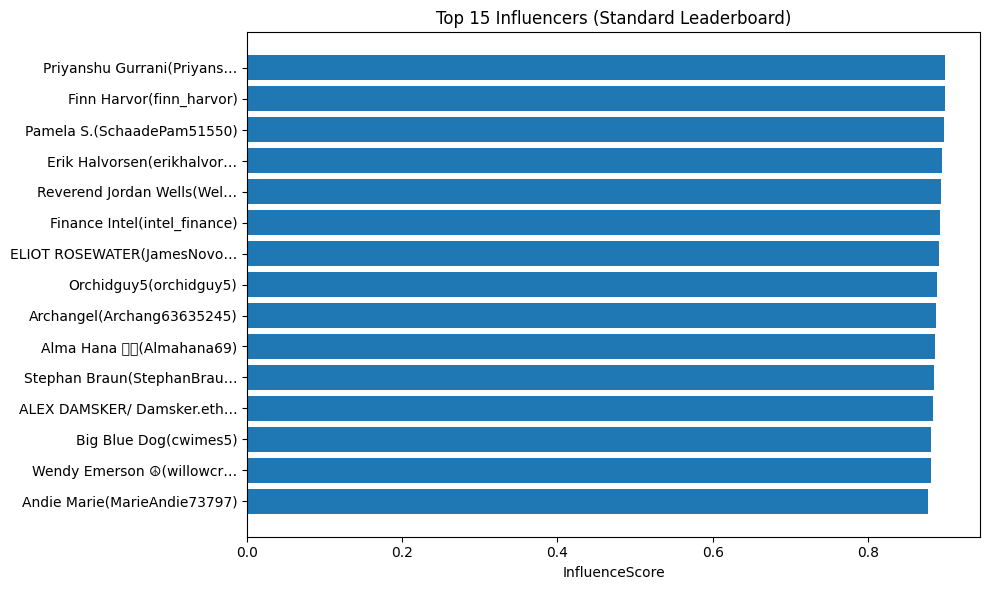

In [ ]:
# -------------STANDARD LEADERBOARD TOP 15 PLOT---------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import os

# Use in-memory df if present; otherwise load from CSV
df = leaderboard_std.copy() if "leaderboard_std" in globals() else pd.read_csv("leaderboard_standard_with_roles.csv")

# Keep only the columns we need and coerce types
df["InfluenceScore"] = pd.to_numeric(df["InfluenceScore"], errors="coerce")
topN = df.nlargest(15, "InfluenceScore").copy()

# Optional: shorten long author strings for the y-axis
def short(a):
    a = str(a)
    return a if len(a) <= 28 else a[:25] + "…"
labels = [short(a) for a in topN["author"]]

plt.figure(figsize=(10, 6))
plt.barh(labels[::-1], topN["InfluenceScore"][::-1])  # reverse so #1 is at top
plt.xlabel("InfluenceScore")
plt.title("Top 15 Influencers (Standard Leaderboard)")
plt.tight_layout()
plt.show()
# plt.savefig("top15_influence.png", dpi=150)  # <- uncomment to save
#-------------------------------------------------------------------------------

***
***
# Strict Leaderboard

Identify the individuals who most effectively shape narrative flow from Twitter/X into traditional media.

- Purpose (STRICT): Conservative, high-confidence measure of influence. Focuses on robust, multi-outlet pickup signals.

- A tweet counts as a “hit” only if ≥ 2 media outlets pick it up.(Adjustable by user in dashboard with knob 'MIN_OUTLETS_STRICT')


Basic Author / Activity Columns:
- rank: Final position on the leaderboard (1 = most influential).
- author: Twitter/X handle or name.
- tweets: Number of tweets by this author in the filtered period.

Cross-Media Impact Columns:
- cross_media_hits: Number of tweets that resulted in at least the required number of media pickups (standard = 1; strict = 2).
- hit_rate: % of the author’s tweets that became hits (cross_media_hits ÷ tweets). Higher = more reliably influential.

Timing & Earliness Columns:
- earliness_mean: Average “earliness” rank of the author’s tweets within each narrative cluster (0 = earliest, 1 = latest). Earlier tweets are more likely to shape coverage.
- lead_days_min_median: Median number of days between a tweet and its earliest confirmed media pickup. Lower = faster influence.
- time_weight: A recency weight (recent tweets count more than older ones, using ~30-day half-life).

Media Breadth & Engagement Columns:
- outlets_median: Typical (median) number of distinct outlets that picked up the author’s hit tweets. Shows breadth of cross-media reach.
- engagement_mean: Average engagement score (likes + retweets + replies). Used lightly, since even low-engagement tweets sometimes get covered.

Normalized Z-Scores (0 to 1 scale):
Standardized versions of the above metrics—allowing them to be combined fairly into an overall influence score.
- Z_hit: Normalized hit rate.
- Z_early: Normalized speed of cross-media pickup.
- Z_speed: Normalized speed of cross-media pickup.
- Z_outlets: Normalized outlet breadth.
- Z_engage: Percentile rank of engagement. (defaults to 0.50 if engagement metrics are not present)
- Z_time: Percentile rank of recency (recent work gets more weight).

InfluenceScore:
- Weighted combination of all Z-metrics.
    - hit rate
    - earliness
    - pickup speed
    - outlet breadth
    - engagement
    - recency

role:
- Automatic classification of the author’s influence style:
    - Originator — early, high hit-rate, fast pickup
    - Amplifier — gets hits but tends to be late
    - Mixed/Low — weak or inconsistent signals

why_ranked:
A short, human-readable summary explaining:
- how many hits they had
- their hit percentage
- how early their tweets were
- their pickup speed

In [ ]:
# -------------TABLE STRICT LEADERBOARD TOP 15- --------------------------------
leaderboard_strict.head(15)
#-------------------------------------------------------------------------------

,rank,author,tweets,cross_media_hits,earliness_mean,outlets_median,lead_days_min_median,engagement_mean,time_weight,hit_rate,Z_hit,Z_early,Z_speed,Z_outlets,Z_engage,Z_time,InfluenceScore,role,why_ranked
0,1,Priyanshu Gurrani(PriyanshuG31640),3,3,0.002913,3.0,0.0,0.0,0.002003,1.0,1.0,0.997087,1.000000,1.0,0.500005,0.002510,0.899543,Originator,"hits=3, hit_rate=100%, early=0%, lead_med=0"
1,2,Finn Harvor(finn_harvor),5,5,0.007430,3.0,0.0,0.0,0.002039,1.0,1.0,0.992570,1.000000,1.0,0.500005,0.005206,0.898775,Originator,"hits=5, hit_rate=100%, early=1%, lead_med=0"
2,3,Pamela S.(SchaadePam51550),3,3,0.014622,3.0,0.0,0.0,0.002113,1.0,1.0,0.985378,1.000000,1.0,0.500005,0.011356,0.897644,Originator,"hits=3, hit_rate=100%, early=1%, lead_med=0"
3,4,Erik Halvorsen(erikhalvorsen18),3,3,0.027731,3.0,0.0,0.0,0.002133,1.0,1.0,0.972269,1.000000,1.0,0.500005,0.012597,0.895084,Originator,"hits=3, hit_rate=100%, early=3%, lead_med=0"
4,5,Reverend Jordan Wells(WellsJorda89710),4,4,0.037851,3.0,0.0,0.0,0.002294,1.0,1.0,0.962149,1.000000,1.0,0.500005,0.033059,0.894083,Originator,"hits=4, hit_rate=100%, early=4%, lead_med=0"
5,6,Finance Intel(intel_finance),3,3,0.045910,3.0,0.0,0.0,0.002362,1.0,1.0,0.954090,1.000000,1.0,0.500005,0.040784,0.892858,Originator,"hits=3, hit_rate=100%, early=5%, lead_med=0"
6,7,ELIOT ROSEWATER(JamesNovot27891),3,3,0.068446,3.0,0.0,0.0,0.003523,1.0,1.0,0.931554,1.000000,1.0,0.500005,0.100947,0.891359,Originator,"hits=3, hit_rate=100%, early=7%, lead_med=0"
7,8,Orchidguy5(orchidguy5),3,3,0.074298,3.0,0.0,0.0,0.002860,1.0,1.0,0.925702,1.000000,1.0,0.500005,0.072204,0.888751,Originator,"hits=3, hit_rate=100%, early=7%, lead_med=0"
8,9,Alma Hana 🇺🇸(Almahana69),3,3,0.083238,3.0,0.0,0.0,0.002917,1.0,1.0,0.916762,1.000000,1.0,0.500005,0.075548,0.88713,Originator,"hits=3, hit_rate=100%, early=8%, lead_med=0"
9,10,Stephan Braun(StephanBraun81),3,3,0.088427,3.0,0.0,0.0,0.002635,1.0,1.0,0.911573,1.000000,1.0,0.500005,0.060209,0.885325,Originator,"hits=3, hit_rate=100%, early=9%, lead_med=0"


### STRICT LEADERBOARD TOP 15 PLOT
Bar chart of the top 15 influencers on the strict leaderboard

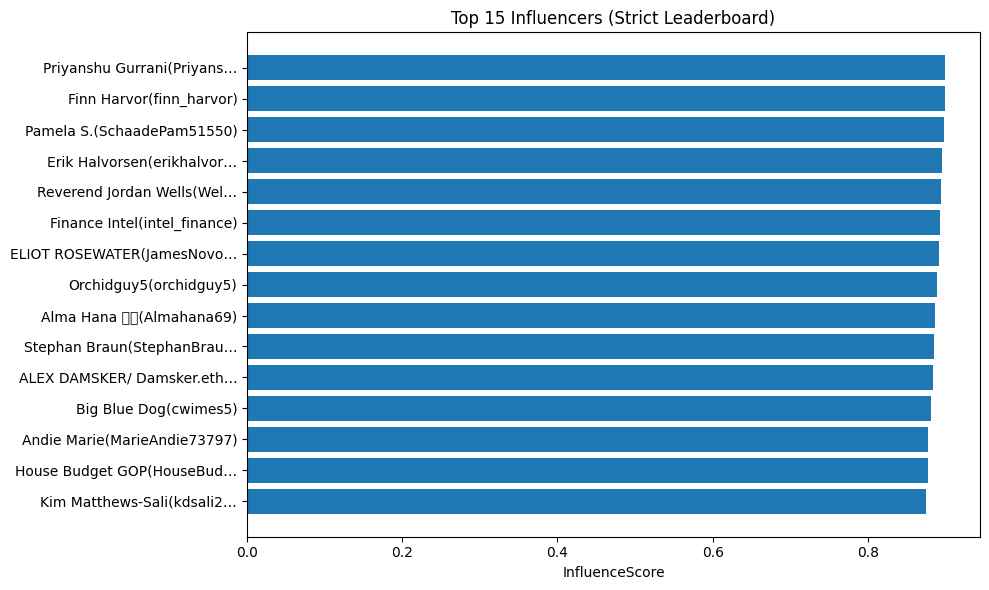

In [ ]:
#-------------STRICT LEADERBOARD TOP 15 PLOT------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import os

# Use in-memory df if present; otherwise load from CSV
df = leaderboard_strict.copy() if "leaderboard_strict" in globals() else pd.read_csv("leaderboard_strict_with_roles.csv")

# Keep only the columns we need and coerce types
df["InfluenceScore"] = pd.to_numeric(df["InfluenceScore"], errors="coerce")
topN = df.nlargest(15, "InfluenceScore").copy()

# shorten long author strings for the y-axis
def short(a):
    a = str(a)
    return a if len(a) <= 28 else a[:25] + "…"
labels = [short(a) for a in topN["author"]]

plt.figure(figsize=(10, 6))
plt.barh(labels[::-1], topN["InfluenceScore"][::-1])  # reverse so #1 is at top
plt.xlabel("InfluenceScore")
plt.title("Top 15 Influencers (Strict Leaderboard)")
plt.tight_layout()
plt.show()
# plt.savefig("top15_influence.png", dpi=150)  # <- uncomment to save
#-------------------------------------------------------------------------------

***
***
# LEADERBOARD AUTHOR ANALYSIS BLOCK
Compares the mix of Originators vs Amplifiers across the Standard and Strict leaderboards.

Visualizes how the stricter definition of a “hit” changes the balance of Originators vs Amplifiers in the influencer rankings.

- Detects which column holds the role labels (Originator / Amplifier / Mixed/Low).
- Calculates what percentage of entries in each leaderboard fall into each role.
- Combines Standard vs Strict into one table.
- Plots a stacked bar chart showing the role composition for:
  - Standard leaderboard
  - Strict leaderboard

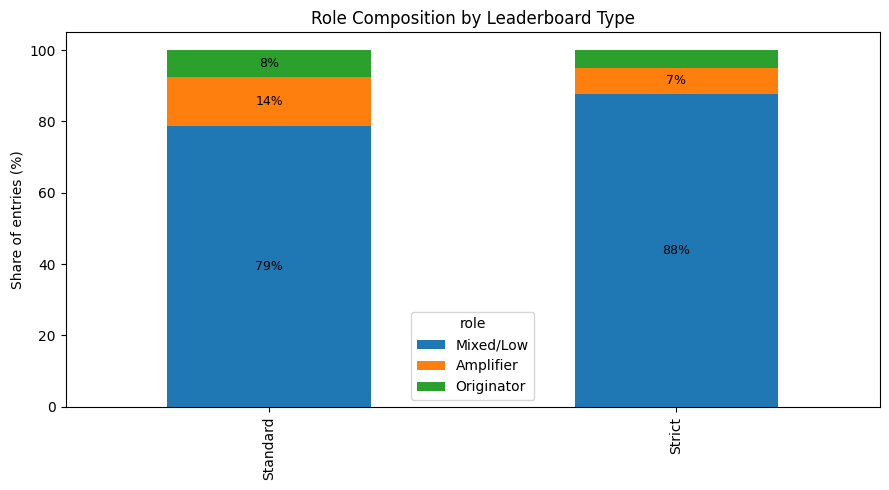

In [ ]:
#----------------------LEADERBOARD AUTHOR ANALYSIS BLOCK------------------------
import pandas as pd
import matplotlib.pyplot as plt


# 2) Detect the role column name
def find_role_col(df):
    for c in df.columns:
        if "role" in c.lower():
            return c
    raise ValueError("No role column found.")
role_col = find_role_col(leaderboard_std)  # assume same name in both

# 3) Compute role percentages
def role_percentages(df, role_col):
    s = df[role_col].value_counts(normalize=True).mul(100)
    return s.rename_axis("role").reset_index(name="pct")

std_pct = role_percentages(leaderboard_std, role_col)
std_pct["leaderboard"] = "Standard"

str_pct = role_percentages(leaderboard_strict, role_col)
str_pct["leaderboard"] = "Strict"

plot_df = pd.concat([std_pct, str_pct], ignore_index=True)

# ensure consistent role order across bars
all_roles = plot_df["role"].unique().tolist()
plot_df["role"] = pd.Categorical(plot_df["role"], categories=all_roles, ordered=True)

# 4) Pivot to wide for stacked plot
wide = plot_df.pivot(index="leaderboard", columns="role", values="pct").fillna(0)

# 5) Plot stacked bar (single chart, no custom colors)
ax = wide.plot(kind="bar", stacked=True, figsize=(9, 5))
ax.set_ylabel("Share of entries (%)")
ax.set_xlabel("")
ax.set_title("Role Composition by Leaderboard Type")
for p in ax.patches:
    # label only larger segments
    if p.get_height() >= 5:
        ax.text(p.get_x()+p.get_width()/2,
                p.get_y()+p.get_height()/2,
                f"{p.get_height():.0f}%",
                ha="center", va="center", fontsize=9)
plt.tight_layout()
plt.show()
#-------------------------------------------------------------------------------

***
***
# TABLE MATCHES
Core bridge between tweets and media articles.
used to determine:
  - Which tweets influenced media coverage
  - When and where narratives propagated
  - How many outlets picked up each tweet (for hit scoring)
  - Timing dynamics (lead/lag)
  - Which authors are originators or amplifiers
  - Narrative-level surge detection and propagation graphs

tweet_row:
- The row index in the unified corpus for the matched tweet.
- Used to map back to the main dataset quickly and consistently.

tweet_author:
- The author/handle of the tweet that triggered the match.
- Important for influence scoring and propagation graph construction.

tweet_doc_id:
- The unique ID of the tweet document from the input file.
- Ensures we can reliably identify and de-duplicate matches.

tweet_time:
- The timestamp of the tweet (UTC).
- Crucial for determining who spoke first and for time-window filtering.

tweet_cluster:
- The narrative cluster ID assigned to that tweet.
- Allows you to link the match back to a specific narrative topic.

media_row:
- The row index in the corpus for the matched news article.
- Used to retrieve metadata (outlet, URL, text) efficiently.

media_outlet:
- The news outlet that published the article (e.g., “Bloomberg,” “Politico”).
- Used for measuring how many distinct outlets picked up a narrative.

media_doc_id:
- The unique article ID from the media dataset.
- Serves as a stable cross-reference.

media_time:
- The timestamp when the media article was published (UTC).
- Used for computing lead_days (tweet → article time difference).

similarity:
- The textual similarity score between tweet and article.
- Depending on configuration chosen by user:
    - TF-IDF cosine similarity
    - Hybrid similarity (TF-IDF + embeddings)
    - Or 1.0 if it was an exact URL match
    - Higher values = stronger evidence the article is covering the same content as the tweet.

lead_days:
  - The number of days between tweet time and article publication.
  - 0 to WINDOW_DAYS → treated as valid propagation (tweet first).
  - Negative values are filtered out earlier.
  - Used directly in influence scoring (early originators vs late amplifiers) and narrative propagation timelines.

evidence:
- Indicates how the match was found:
  - "url" → exact URL match (strongest signal)
  - "text" → similarity match (semantic or TF-IDF)
- helps distinguish:
  - exact evidence (article explicitly referenced)
  - semantic evidence (article covers same topic but not linked)

In [ ]:
#----------------TABLE MATCHES block--------------------------------------------
matches.head(20)
#-------------------------------------------------------------------------------

,tweet_row,tweet_author,tweet_doc_id,tweet_time,tweet_cluster,media_row,media_outlet,media_doc_id,media_time,similarity,lead_days,evidence
0,0,Libs of TikTok(libsoftiktok),1895983811449795072,2025-06-17 20:35:16.386000+00:00,1,265781,Bloomberg,https://www.bloomberg.com/opinion/articles/202...,2025-06-22 12:00:38.250000+00:00,0.346345,4,text
1,0,Libs of TikTok(libsoftiktok),1895983811449795072,2025-06-17 20:35:16.386000+00:00,1,265451,Bloomberg Government,nan,2025-06-18 11:00:00+00:00,0.329472,0,text
2,0,Libs of TikTok(libsoftiktok),1895983811449795072,2025-06-17 20:35:16.386000+00:00,1,265736,Politico,https://www.politico.com/news/2025/06/20/senat...,2025-06-20 22:03:00+00:00,0.326280,3,text
3,1,Mario Nawfal(marionawfal),1895966025427943936,2025-06-17 20:35:16.389000+00:00,6,265482,Salon,https://www.salon.com/2025/06/18/in-sadness-i-...,2025-06-18 14:13:45+00:00,0.347019,0,text
4,1,Mario Nawfal(marionawfal),1895966025427943936,2025-06-17 20:35:16.389000+00:00,6,265411,The Guardian,112529638,2025-06-18 00:00:00+00:00,0.323479,0,text
5,4,Mario Nawfal(marionawfal),1896273093946949888,2025-06-17 20:35:16.510000+00:00,3,265541,Punchbowl News,https://punchbowl.news/archive/61825-pm/,2025-06-18 21:19:17+00:00,0.338748,1,text
7,4,Mario Nawfal(marionawfal),1896273093946949888,2025-06-17 20:35:16.510000+00:00,3,266139,The Hill,https://thehill.com/policy/healthcare/5367133-...,2025-06-24 19:18:17+00:00,0.316317,6,text
8,5,Libs of TikTok(libsoftiktok),1896234990884777984,2025-06-17 20:35:16.514000+00:00,1,265443,The Hill,https://thehill.com/policy/healthcare/5355932-...,2025-06-18 10:00:00+00:00,0.327474,0,text
9,5,Libs of TikTok(libsoftiktok),1896234990884777984,2025-06-17 20:35:16.514000+00:00,1,265736,Politico,https://www.politico.com/news/2025/06/20/senat...,2025-06-20 22:03:00+00:00,0.319844,3,text
10,5,Libs of TikTok(libsoftiktok),1896234990884777984,2025-06-17 20:35:16.514000+00:00,1,265451,Bloomberg Government,nan,2025-06-18 11:00:00+00:00,0.317976,0,text


***
***
# NARRATIVE PROPAGATION SPEED BLOCK

Measures and visualizes how fast different narratives jump from Twitter/X into the media.

Shows which narratives propagate fastest from tweets to news coverage, and with how much supporting evidence per narrative.

- It takes the matches table, keeps valid tweet_cluster + lead_days pairs, and computes for each cluster:
  - median_lead = median tweet→media lag in days
  - n = number of matches used (so tiny/noisy clusters can be dropped).
- Optionally attaches human-readable narrative labels using narr_top_terms.
- Filters out clusters with very few matches, then plots a horizontal bar chart showing the median lead time per narrative, annotated with median_lead and n.

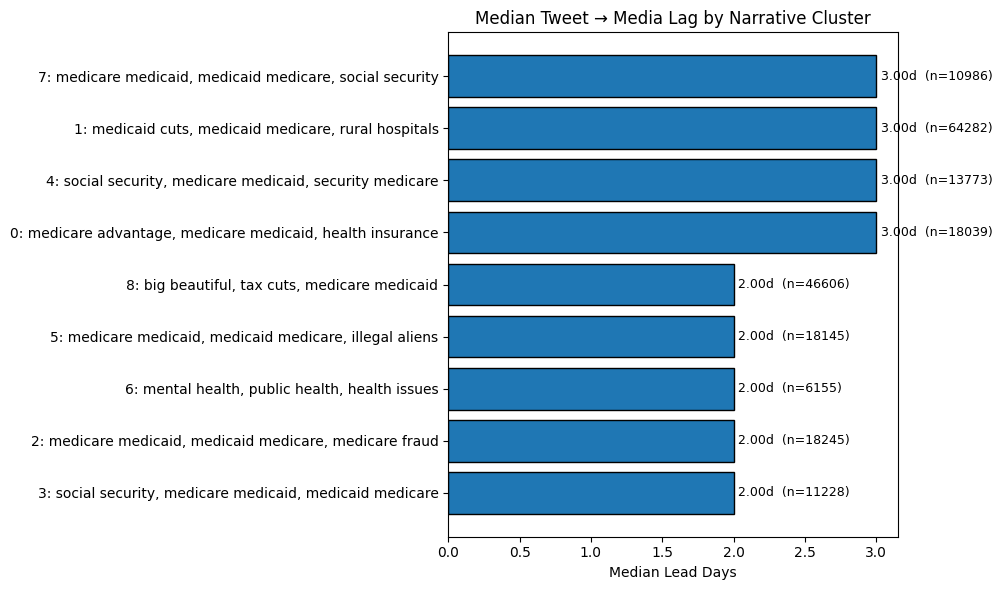

In [ ]:
#--------------NARRATIVE PROPAGATION SPEED BLOCK--------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Build a tidy table: cluster → median lead + count
df = (matches
      .dropna(subset=["tweet_cluster","lead_days"])
      .assign(tweet_cluster=lambda d: d["tweet_cluster"].astype(int),
              lead_days=lambda d: pd.to_numeric(d["lead_days"], errors="coerce"))
      .query("lead_days >= 0")
)

agg = (df.groupby("tweet_cluster")
         .agg(median_lead=("lead_days","median"),
              n=("lead_days","size"))
         .reset_index())

# filter out tiny clusters (to avoid noisy medians)
MIN_N = 25
agg = agg.query("n >= @MIN_N")

# human-readable cluster labels if you have narr_top_terms (Series: cluster_id → list/str)
def label_cluster(c):
    if 'narr_top_terms' in globals():
        terms = narr_top_terms.get(int(c), [])
        if isinstance(terms, (list, tuple)): terms = ", ".join(terms[:3])
        return f"{int(c)}: {terms}"
    return str(int(c))

agg["cluster_label"] = agg["tweet_cluster"].map(label_cluster)

# Order by median lead
agg = agg.sort_values("median_lead", ascending=True)

# Plot with annotations
plt.figure(figsize=(10, 6))
bars = plt.barh(agg["cluster_label"], agg["median_lead"], edgecolor="black")
plt.xlabel("Median Lead Days")
plt.title("Median Tweet → Media Lag by Narrative Cluster")

# annotate median + n on bars
for b, med, n in zip(bars, agg["median_lead"], agg["n"]):
    plt.text(b.get_width() + 0.03, b.get_y() + b.get_height()/2,
             f"{med:.2f}d  (n={n})", va="center", fontsize=9)

plt.tight_layout()
plt.show()
#-------------------------------------------------------------------------------

***
***
# TOP 15 MEDIA OUTLETS BY TWEET MATCHES
Highlights the main outlets that are amplifying content from Twitter/X
- Counts how many tweet→article matches each media_outlet has.
- Takes the top 15 outlets by match count.
- Plots a horizontal bar chart: outlet on the y-axis, number of matched tweets on the x-axis.

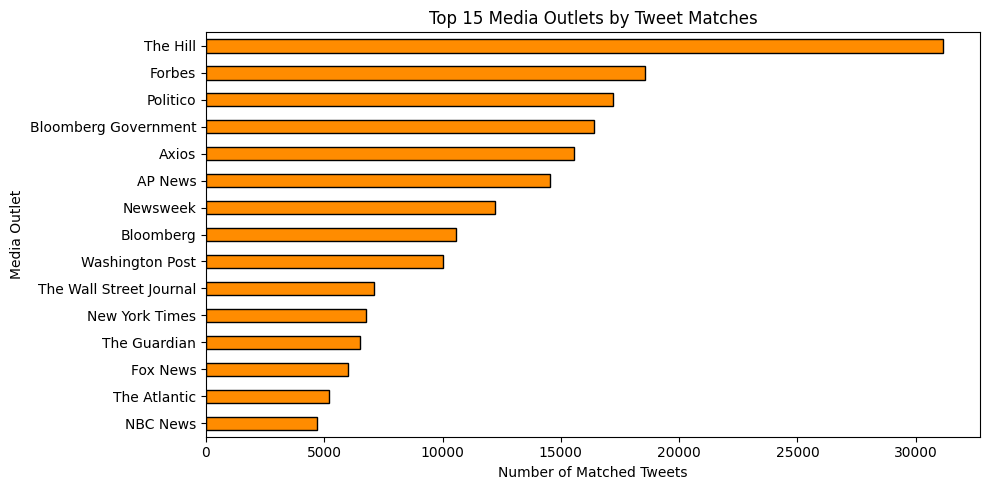

In [ ]:
#---------------------TOP 15 MEDIA OUTLETS BY TWEET MATCHES---------------------
top_outlet_counts = matches["media_outlet"].value_counts().head(15)

plt.figure(figsize=(10, 5))
top_outlet_counts[::-1].plot(kind="barh", color="darkorange", edgecolor="black") # reverse order
plt.title("Top 15 Media Outlets by Tweet Matches")
plt.xlabel("Number of Matched Tweets")
plt.ylabel("Media Outlet")
plt.tight_layout()
plt.show()
#-------------------------------------------------------------------------------

***
***
# NARRATIVE CLUSTERS TOP TERMS TABLE
Extracts descriptive keywords/phrases for each narrative cluster using TF-IDF.

Creates a table of “top terms per narrative” that you can use to label or interpret each cluster.

- It sets pandas display options so you can see full term lists.
- Uses the fitted tfidf_vec to get feature_names (the vocabulary).
- top_terms_by_cluster(...):
  - Averages TF-IDF vectors within each cluster.
  - Finds the top topk terms with highest average TF-IDF for that cluster.
- Builds narr_top_terms, a Series mapping cluster → [top terms].

In [ ]:
#-------------NARRATIVE CLUSTERS TOP TERMS TABLE--------------------------------
import numpy as np
import pandas as pd

pd.set_option('display.max_colwidth', None)   # don’t truncate long cells
pd.set_option('display.width', None)          # don’t wrap lines

feature_names = np.array(tfidf_vec.get_feature_names_out())

def top_terms_by_cluster(X_tfidf, labels, topk=12):
    # average TF-IDF vector inside each narrative cluster
    out = {}
    for c in np.sort(pd.unique(labels)):
        mask = (labels == c)
        if mask.sum() == 0:
            out[c] = []
            continue
        mean_vec = X_tfidf[mask].mean(axis=0).A1  # dense row
        idx = np.argsort(mean_vec)[::-1][:topk]
        out[c] = feature_names[idx].tolist()
    return pd.Series(out, name="top_terms")

narr_top_terms = top_terms_by_cluster(X_tfidf, corpus["cluster"].values, topk=12)
narr_top_terms
#-------------------------------------------------------------------------------

,top_terms
0,"[medicare, insurance, advantage, care, medicare advantage, healthcare, medicaid, medicare medicaid, health, pay, patients, plans]"
1,"[medicaid, cuts, budget, changes, rural, people, medicare, medicaid cuts, hospitals, cut, care, medicaid medicare]"
2,"[medicare, medicaid, fraud, medicare medicaid, medicaid medicare, medicare fraud, senrickscott, trump, social security, security, social, people]"
3,"[medicare, medicaid, social, security, social security, medicare medicaid, trump, medicaid medicare, security medicare, people, republicans, democrats]"
4,"[medicare, medicaid, social, security, social security, medicare medicaid, pay, tax, taxes, security medicare, money, government]"
5,"[illegals, illegal, medicare, medicaid, immigrants, medicare medicaid, medicaid medicare, aliens, illegal aliens, undocumented, citizens, benefits]"
6,"[mental, health, mental health, public, public health, tobacco, care, shortage, support, new, people, like]"
7,"[medicare, medicaid, medicare medicaid, medicaid medicare, people, pay, don, care, social, security, social security, insurance]"
8,"[cuts, medicaid, tax, cut, trump, big, medicare, budget, beautiful, big beautiful, tax cuts, snap]"


***
***
# NARRATIVE CLUSTER STATS BLOCK
Summarizes the basic size and composition of each narrative cluster.

Builds a per-cluster stats table so you can see which narratives are biggest, how many voices/outlets they involve, and their tweet/media mix.

- core: For each cluster, computes:
  - n_docs – total documents (tweets + media),
  - prop – share of the entire corpus,
  - n_authors – unique tweet authors,
  - n_outlets – unique media outlets.
- split: Separately counts how many tweets vs media articles each cluster has (n_tweets, n_media).
- Merges these into cluster_stats_table, sorted by n_docs.

In [ ]:
#-----------------NARRATIVE CLUSTER STATS BLOCK---------------------------------
# Core per-cluster stats (excluding tweet/media counts)
core = (corpus.groupby("cluster")
        .agg(
            n_docs   = ("doc_id", "size"),
            prop     = ("doc_id", lambda s: len(s) / len(corpus)),
            n_authors= ("author", "nunique"),
            n_outlets= ("outlet", "nunique"),
        )
        .reset_index())

# Explicit tweet/media split
split = (corpus.pivot_table(index="cluster", columns="_kind",
                            values="doc_id", aggfunc="size", fill_value=0)
               .rename(columns={"tweet":"n_tweets", "media":"n_media"})
               .reset_index())

# Merge once; no duplicate n_tweets
comp = (core.merge(split, on="cluster", how="left")
             .loc[:, ["cluster","n_docs","prop","n_authors","n_outlets","n_tweets","n_media"]]
             .sort_values("n_docs", ascending=False))
cluster_stats_table = comp.sort_values("n_docs", ascending=False)
cluster_stats_table
#-------------------------------------------------------------------------------

,cluster,n_docs,prop,n_authors,n_outlets,n_tweets,n_media
0,0,37128,0.135243,18988,25,36160,968
2,2,36934,0.134536,22616,20,36882,52
1,1,36010,0.131171,16133,27,35189,821
3,3,30576,0.111377,17809,30,29606,970
7,7,29791,0.108517,18348,4,29782,9
6,6,27072,0.098613,14937,32,20585,6487
8,8,26087,0.095025,12290,30,24667,1420
5,5,26015,0.094763,15143,18,25948,67
4,4,24915,0.090756,14501,20,24748,167


***
***
# NARRTIVE AUTO-LABELER
Creates short, human-readable labels for each narrative cluster using the previously computed top terms.

Auto-generates simple narrative names from top terms so you can label clusters in tables, plots, and the UI.

- narr_label_from_terms takes a list of top terms for a cluster and joins the first few (default 4) into a compact phrase.

- narr_labels builds a dictionary:
cluster_id → "term1, term2, term3, term4"

In [ ]:
#--------------NARRTIVE AUTO-LABELER--------------------------------------------
# Build compact labels from the top terms above
def narr_label_from_terms(terms, k=4):
    return ", ".join(terms[:k])

narr_labels = {int(cid): narr_label_from_terms(terms) for cid, terms in narr_top_terms.items()}
narr_labels  # {0: "...", 1: "...", ...}
#-------------------------------------------------------------------------------

{0: 'medicare, insurance, advantage, care',
 1: 'medicaid, cuts, budget, changes',
 2: 'medicare, medicaid, fraud, medicare medicaid',
 3: 'medicare, medicaid, social, security',
 4: 'medicare, medicaid, social, security',
 5: 'illegals, illegal, medicare, medicaid',
 6: 'mental, health, mental health, public',
 7: 'medicare, medicaid, medicare medicaid, medicaid medicare',
 8: 'cuts, medicaid, tax, cut'}

***
***
# 2-D NARRATIVE-CLUSTER PROJECTION BLOCK

Creates a 2D visual map of the narrative clusters so you can see how documents group together.

Projects the narrative space into 2D and visualizes how tweets and articles cluster into narratives, plus where each cluster’s center lies.

- embed_2d(...) reduces high-dimensional representations (embeddings E or TF-IDF X_tfidf) down to two components using TruncatedSVD + PCA or PCA alone.
- Computes (x, y) coordinates for each document, attaches its cluster and _kind (tweet vs media).
- Optionally samples if there are too many points.
- Plots:
  - Tweets as one marker, media as another,
  - Cluster centroids as big “X” markers.

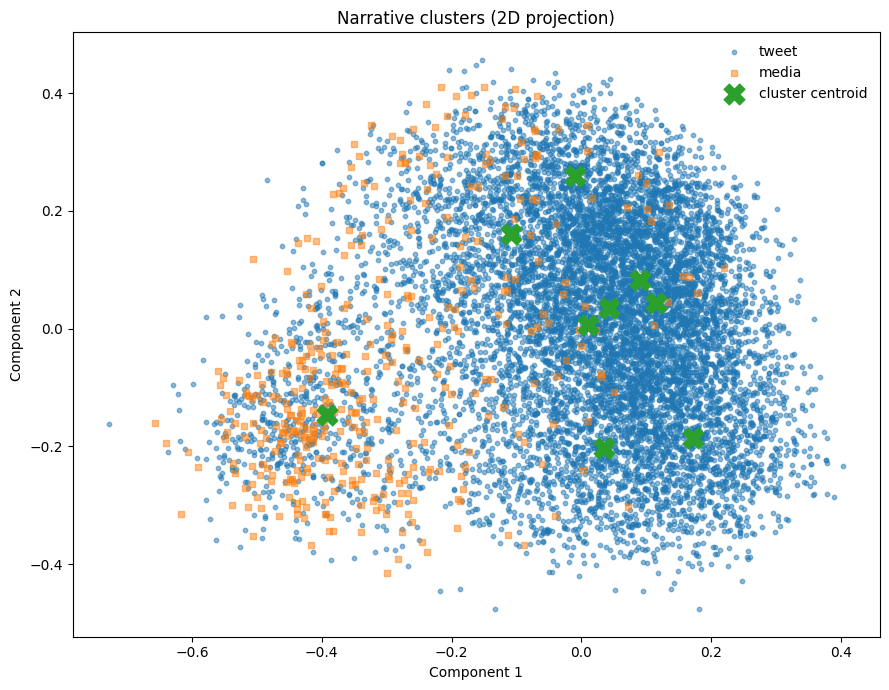

In [ ]:
#----------------2-D NARRATIVE-CLUSTER PROJECTION BLOCK-------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, TruncatedSVD

labels = corpus["cluster"].to_numpy()

def embed_2d(E=None, X=None, n_pre=50, seed=42):
    """
    Returns 2D coordinates for each row in E or X.
    - If E (dense embeddings) is provided: PCA -> 2D
    - Else: TruncatedSVD (sparse-safe) -> PCA -> 2D
    """
    if E is not None:
        Z = E
        if hasattr(Z, "toarray"): Z = Z.toarray()
        pca = PCA(n_components=2, random_state=seed)
        XY = pca.fit_transform(Z)
        return XY
    elif X is not None:
        # Reduce sparse TF-IDF safely
        svd = TruncatedSVD(n_components=min(n_pre, X.shape[1]-1), random_state=seed)
        Z = svd.fit_transform(X)
        pca = PCA(n_components=2, random_state=seed)
        XY = pca.fit_transform(Z)
        return XY
    else:
        raise ValueError("Provide E (embeddings) or X (TF-IDF).")

XY = embed_2d(E=E, X=X_tfidf)

# optional: sample if huge
max_pts = 10000
if len(XY) > max_pts:
    idx = np.random.RandomState(42).choice(len(XY), size=max_pts, replace=False)
else:
    idx = np.arange(len(XY))

dfp = (pd.DataFrame(XY, columns=["x","y"])
         .assign(cluster=labels, kind=corpus["_kind"].to_numpy()))
dfp = dfp.iloc[idx].reset_index(drop=True)

plt.figure(figsize=(9,7))
# tweet vs media with different markers
for kind, marker in [("tweet","o"), ("media","s")]:
    m = (dfp["kind"]==kind)
    plt.scatter(dfp.loc[m,"x"], dfp.loc[m,"y"],
                s=10 if kind=="tweet" else 25, marker=marker, alpha=0.5, label=kind)
plt.title("Narrative clusters (2D projection)")
plt.xlabel("Component 1"); plt.ylabel("Component 2")
# outline cluster centroids
cent = dfp.groupby("cluster")[["x","y"]].mean()
plt.scatter(cent["x"], cent["y"], s=220, marker="X", label="cluster centroid")
plt.legend(frameon=False, loc="best")
plt.tight_layout()
plt.show()
#-------------------------------------------------------------------------------

## NARRATIVE CENTROIDS PLOT

Plots each narrative cluster as a single labeled point, sized by how big the cluster is.

Gives a clean “map of narratives” where you see where each narrative sits in 2D space and how large it is.

- Uses the 2D coordinates (XY) to compute the centroid (average x,y) for each cluster.
- Counts how many documents each cluster has (n_docs) and scales the marker size accordingly.
- Plots one point per cluster and labels it with either:
  - the auto-generated narrative label, or
  - the cluster ID.

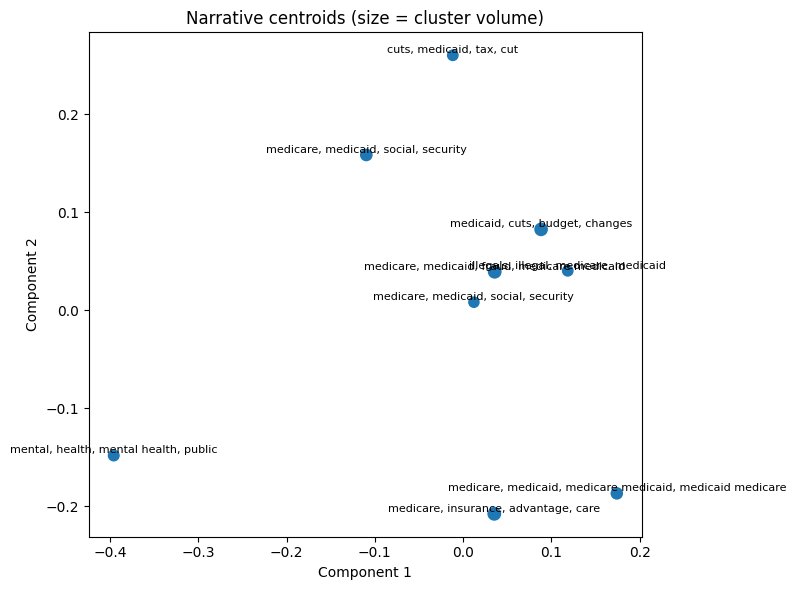

In [ ]:
#---------------NARRATIVE CENTROIDS PLOT----------------------------------------
comp = (corpus.groupby("cluster")["doc_id"].size()
        .rename("n_docs").reset_index())
cent = (pd.DataFrame(XY, columns=["x","y"])
        .assign(cluster=labels)
        .groupby("cluster")[["x","y"]].mean()
        .reset_index()
        .merge(comp, on="cluster", how="left"))

plt.figure(figsize=(8,6))
sizes = 80 * (cent["n_docs"] / cent["n_docs"].max()).clip(0.2, 1.0)
plt.scatter(cent["x"], cent["y"], s=sizes)
for _, r in cent.iterrows():
    label = narr_labels.get(int(r["cluster"]), str(int(r["cluster"]))) if "narr_labels" in globals() else str(int(r["cluster"]))
    plt.text(r["x"], r["y"], label, fontsize=8, ha="center", va="bottom")
plt.title("Narrative centroids (size = cluster volume)")
plt.xlabel("Component 1"); plt.ylabel("Component 2")
plt.tight_layout(); plt.show()
#-------------------------------------------------------------------------------

***
***
# IDENTIFY INFLUENCER EXEMPLARS BLOCK
Picks “example influencers” for each influencer-cluster archetype.
- Merges the standard leaderboard (InfluenceScore per author) with the influencer_clusters table (which inf_cluster each author belongs to).

- For each inf_cluster, it selects the top k authors (default 5) ranked by InfluenceScore.

- The result, inf_exemplars, is a small table to show representative high-impact authors for each influencer type (e.g., “Cluster 0: here are 5 exemplar accounts”).

In [ ]:
#-----------IDENTIFY INFLUENCER EXEMPLARS BLOCK---------------------------------

# join leaderboard (for score) and pick exemplars
exemplars = (leaderboard_std[["author","InfluenceScore"]]
             .merge(influencer_clusters[["author","inf_cluster"]], on="author", how="inner"))

def top_authors_per_infcluster(df, k=5):
    rows = []
    for c, g in df.groupby("inf_cluster"):
        gg = g.sort_values("InfluenceScore", ascending=False).head(k)
        for _, r in gg.iterrows():
            rows.append({"inf_cluster": int(c), "author": r["author"], "InfluenceScore": r["InfluenceScore"]})
    return pd.DataFrame(rows)

inf_exemplars = top_authors_per_infcluster(exemplars, k=5)
#-------------------------------------------------------------------------------

### TABLE INFLUENCER EXEMPLARS
Turns the raw influencer-cluster exemplars into a human-readable table.

Enriches each influencer archetype with concrete exemplar accounts and example posts, so you can explain and illustrate what each influencer cluster “looks like” in practice.

- Builds a persona-style label for each influencer cluster (persona_label), using the top narratives that cluster tends to engage with.
- For each exemplar author, adds:
  - n_tweets – how many tweets they have in the corpus.
  - n_hits – how many of those tweets became cross-media hits.
  - hit_rate – n_hits / n_tweets.
  - sample_post – a cleaned, truncated example tweet from that author (latest one).
- Produces a inf_exemplars table with columns:
  - inf_cluster, persona_label, author, InfluenceScore,
  - n_tweets, n_hits, hit_rate, sample_post.

In [ ]:
#-------------------TABLE INFLUENCER EXEMPLARS ---------------------------------
import re

def persona_label(cid):
    # uses the top_narratives_per_cluster + narr_labels if available
    try:
        tops = top_narratives_per_cluster.get(int(cid), [])
        names = [narr_labels.get(int(n), str(n)) for n in tops[:2]]
        return " / ".join([n for n in names if n]) or f"Cluster {cid}"
    except Exception:
        return f"Cluster {cid}"

# volumes & hits per author
tw_only = corpus[corpus["_kind"]=="tweet"].copy()
author_counts = tw_only.groupby("author").size().rename("n_tweets")
author_hits   = (tw_only.assign(hit=(tw_only["cross_media_hit"]==1))
                          .groupby("author")["hit"].sum()
                          .rename("n_hits"))

# latest text per author
def pretty(s, n=140):
    s = re.sub(r"https?://\S+","", str(s) or "")
    s = re.sub(r"\s+"," ", s).strip()
    return (s[:n] + "…") if len(s) > n else s

latest_text = (tw_only.sort_values("time", ascending=False)
                      .groupby("author").first()["_text"].map(pretty))

inf_exemplars = (inf_exemplars
    .merge(author_counts, on="author", how="left")
    .merge(author_hits,   on="author", how="left")
    .assign(hit_rate=lambda d: (d["n_hits"] / d["n_tweets"]).fillna(0),
            persona_label=lambda d: d["inf_cluster"].map(persona_label),
            sample_post=lambda d: d["author"].map(latest_text))
    .fillna({"n_tweets":0, "n_hits":0})
    .sort_values(["inf_cluster","InfluenceScore"], ascending=[True, False])
    [["inf_cluster","persona_label","author","InfluenceScore","n_tweets","n_hits","hit_rate","sample_post"]]
)
inf_exemplars.head(20)
#-------------------------------------------------------------------------------

,inf_cluster,persona_label,author,InfluenceScore,n_tweets,n_hits,hit_rate,sample_post
0,0,Cluster 0,KPRC 2 Houston(KPRC2),0.815922,5,5,1.0,Focus on first responders' mental health grows as death toll rises in flood-ravaged Texas
1,0,Cluster 0,InstantHPI - An AI Butler Service for Doctors(DrFontAi),0.762699,3,3,1.0,"Telehealth powered by AI is poised to revolutionize healthcare, cutting costs &amp; boosting efficiency. Imagine robots doing blood draws at…"
2,0,Cluster 0,Abtisam Mohamed(Abtisam_Mohamed),0.760584,3,3,1.0,"Community representatives, youth and mental health professionals discussed the key findings from new research surrounding Young Men, Mental …"
3,0,Cluster 0,Stu Pedasso(abolish_the_lRS),0.756436,3,3,1.0,@Steve1oftheMany @MsCharlotteWWE It’s men’s mental health awareness month
4,0,Cluster 0,Jim Burnetti(JBurnetti),0.749550,4,4,1.0,@WhiteHouse @POTUS Another shooting in Texas connected to mental health issues. MAKE DC SAFE AGAIN.🇺🇸 Restrict Trump to Mar A Lago.
5,1,Cluster 1,Archangel(Archang63635245),0.887222,3,3,1.0,"Please email Senators today, ask them not to let bill HR1 cut Medicaid or Medicare. ‘Look my child in the eye’: Parent confronts GOP over Me…"
6,1,Cluster 1,House Budget GOP(HouseBudgetGOP),0.877509,8,8,1.0,.@RepBuddyCarter “We have an obligation to preserve Medicaid for those who truly need it while also protecting hardworking taxpayer dollars.…
7,1,Cluster 1,WhiteHelljumper(WhiteHelljumper),0.876815,3,3,1.0,@thatguymike_92 @DelusionPosting We do spend a lot more per capita on healthcare than other countries. Medicare and Medicaid are basically m…
8,1,Cluster 1,Sláinte....U.S. Go Bragh(1stSvelteCelt),0.868165,3,3,1.0,Trump's military parade will not accomplish a single thing. It's a microcosm of this administration's bigger budget priorities. President Tr…
9,1,Cluster 1,Brian James(BrianJ5881166),0.867214,14,13,0.928571,@RepHaridopolos Randomly cutting Medicaid to 11 million vulnerable Americans in need of critical healthcare services is not strengthening it…


### TOP AUTHORS PER INFLUNCER PERSONA PLOT
Visualizes the top influencers inside each influencer persona/cluster.

Gives a clear visual of the top authors within each influencer persona, showing who leads each influencer type and how strong they are.

- Takes the already-built inf_exemplars table and keeps the top 5 authors per inf_cluster.
- Assigns a distinct color to each influencer cluster (persona).
- Plots a horizontal bar chart where:
  - Each bar = an author,
  - Grouped and colored by their influencer cluster,
  - X-axis = InfluenceScore,
  - Y-axis label = "cluster – author".
Adds exact InfluenceScore labels on the bars and a legend keyed to influencer clusters.

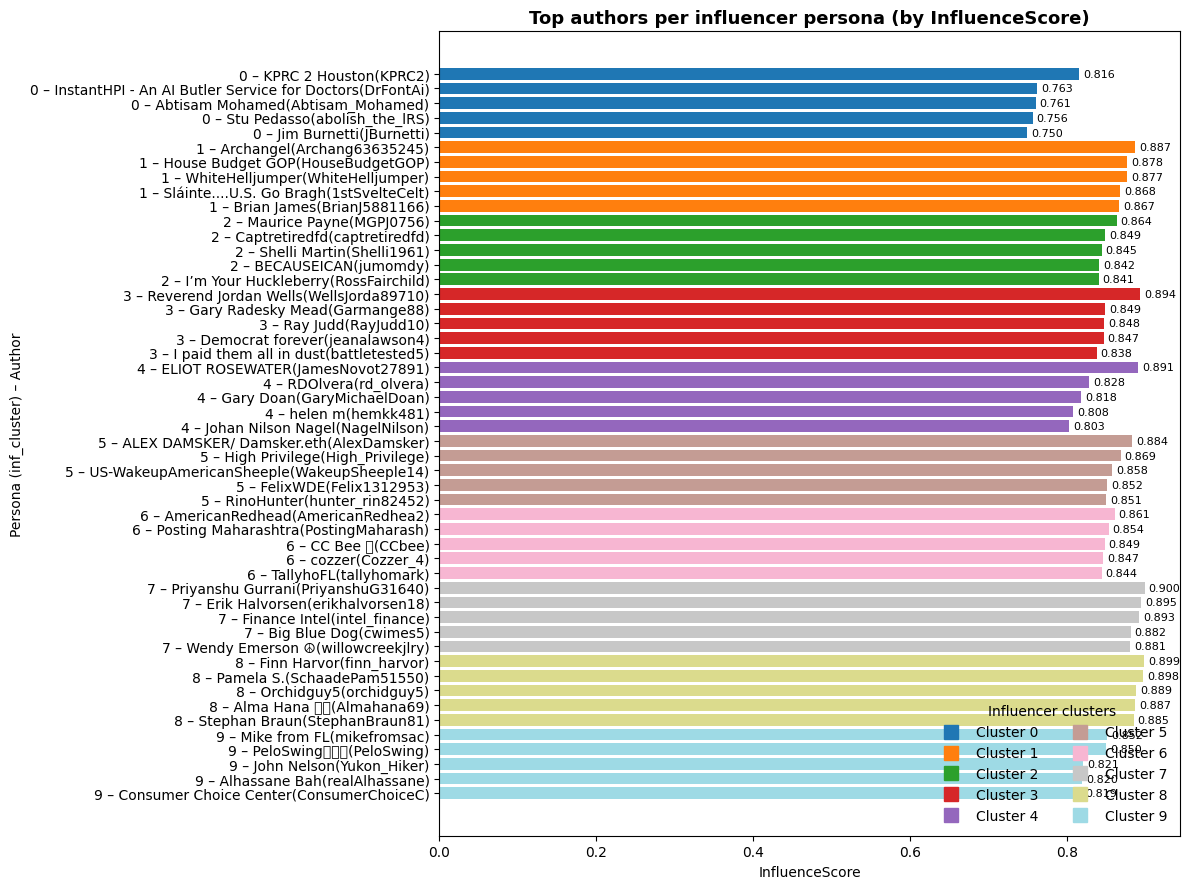

In [ ]:
#--------------------TOP AUTHORS PER INFLUNCER PERSONA PLOT---------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# Take the top-K authors per persona that was already built
g = inf_exemplars.groupby("inf_cluster").head(5).copy()

# Stable color map: one color per cluster (use new API)
clusters = np.sort(g["inf_cluster"].unique())
n_clusters = len(clusters)
cmap = matplotlib.colormaps.get_cmap("tab20").resampled(max(n_clusters, 1))  # resample to n colors
cluster_to_color = {c: cmap(i / max(n_clusters-1, 1)) for i, c in enumerate(clusters)}

# Colors and labels
colors = g["inf_cluster"].map(cluster_to_color)
ylabels = [f"{c} – {a}" for c, a in zip(g["inf_cluster"], g["author"])]

# Plot
fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(ylabels, g["InfluenceScore"], color=colors, edgecolor="none")
ax.invert_yaxis()
ax.set_title("Top authors per influencer persona (by InfluenceScore)", fontsize=13, weight="bold")
ax.set_xlabel("InfluenceScore")
ax.set_ylabel("Persona (inf_cluster) – Author")

# annotate scores
for b, s in zip(bars, g["InfluenceScore"]):
    ax.text(b.get_width() + 0.005, b.get_y() + b.get_height()/2, f"{s:.3f}", va="center", fontsize=8)

# Legend
handles = [plt.Line2D([0],[0], marker='s', linestyle='', color=cluster_to_color[c],
                      label=f"Cluster {c}", markersize=10) for c in clusters]
ax.legend(handles=handles, title="Influencer clusters", frameon=False, ncol=2, loc="lower right")

plt.tight_layout()
plt.show()
#-------------------------------------------------------------------------------

***
***
# TABLE TOP INFLUNCERS PER NARRATIVE TABLE

Builds a table of the top influencers for each specific narrative (not just overall).

Creates a “top influencers per narrative” table, showing who most strongly drives each specific narrative.

- Starts from auth_narr_norm (each author’s share of tweets per narrative).
- Brings in each author’s overall InfluenceScore and total tweet volume.
- Keeps only authors who:
  - Have at least MIN_TWEETS total tweets, and
  - Devote at least MIN_SHARE (e.g., 15%) of their posts to that narrative.
- Computes a NarrativeInfluence score = InfluenceScore × share (how strong + how focused they are on that narrative).
- For each narrative (narr_id), picks the top K authors and ranks them.
- Optionally adds a human-readable narrative label.

In [ ]:
#------------------TABLE TOP INFLUNCERS PER NARRATIVE TABLE---------------------
import pandas as pd
import numpy as np

# --- Config ---
TOPK_PER_NARR = 15   # how many authors to return per narrative
MIN_SHARE  = 0.15  # author must devote at least 15% of posts to that narrative
MIN_TWEETS  = 3  # author must have at least this many tweets overall (from the corpus)

# 1) Long table of (author, narr_id, share_of_posts)
mix_long = (auth_narr_norm
            .reset_index()                                     # index is author
            .melt(id_vars="author", var_name="narr_id", value_name="share"))

# 2) Bring in author-level influence & volume
# If already built 'author_counts' earlier, it can be reused; otherwise recompute quickly:
author_counts = (corpus.loc[corpus["_kind"]=="tweet"]
                      .groupby("author").size().rename("n_tweets"))

authors_scored = (leaderboard_std[["author","InfluenceScore"]]
                  .merge(author_counts, on="author", how="left"))

# 3) Combine and compute a narrative-specific score
rank_basis = (mix_long
              .merge(authors_scored, on="author", how="left")
              .fillna({"share":0.0, "n_tweets":0})
              .query("n_tweets >= @MIN_TWEETS and share >= @MIN_SHARE")
             )

# Narrative-specific influence score (simple and effective)
rank_basis["NarrativeInfluence"] = rank_basis["InfluenceScore"] * rank_basis["share"]

# 4) Rank top authors per narrative
def top_authors_per_narr(df, k=TOPK_PER_NARR):
    rows = []
    for nid, g in df.groupby("narr_id"):
        gg = g.sort_values("NarrativeInfluence", ascending=False).head(k)
        gg = gg.assign(rank=range(1, len(gg)+1), narr_id=nid)
        rows.append(gg)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

top_by_narr = (top_authors_per_narr(rank_basis)
               .sort_values(["narr_id","rank"])
               [["narr_id","rank","author","NarrativeInfluence","InfluenceScore","share","n_tweets"]])

# 5) Optional: add human-readable narrative labels
if "narr_labels" in globals():
    top_by_narr["narr_label"] = top_by_narr["narr_id"].map(lambda c: narr_labels.get(int(c), str(int(c))))
    cols = ["narr_id","narr_label","rank","author","NarrativeInfluence","InfluenceScore","share","n_tweets"]
    top_by_narr = top_by_narr[cols]

top_by_narr.head(30)   # view a sample
#-------------------------------------------------------------------------------

,narr_id,narr_label,rank,author,NarrativeInfluence,InfluenceScore,share,n_tweets
0,0,"medicare, insurance, advantage, care",1,Consumer Choice Center(ConsumerChoiceC),0.818811,0.818811,1.000000,3.0
1,0,"medicare, insurance, advantage, care",2,Jenn 💫(Jenna_OrangeCo),0.791663,0.791663,1.000000,3.0
2,0,"medicare, insurance, advantage, care",3,American Academy of Neurology(AANmember),0.769814,0.769814,1.000000,3.0
3,0,"medicare, insurance, advantage, care",4,Rollover Mitchell(mnahmanson),0.763357,0.763357,1.000000,4.0
4,0,"medicare, insurance, advantage, care",5,InfoVision Healthcare(InfovisionH),0.741688,0.741688,1.000000,8.0
5,0,"medicare, insurance, advantage, care",6,Jones Day(JonesDay),0.741247,0.741247,1.000000,5.0
6,0,"medicare, insurance, advantage, care",7,Doug Kurz(warblers4me),0.740502,0.740502,1.000000,3.0
7,0,"medicare, insurance, advantage, care",8,Senior Care Pharmacy Coalition(SeniorCareRx),0.729267,0.729267,1.000000,4.0
8,0,"medicare, insurance, advantage, care",9,Sarah Karlin-Smith(SarahKarlin),0.718629,0.718629,1.000000,4.0
9,0,"medicare, insurance, advantage, care",10,Dividend Dude(DividendDude_X),0.718458,0.718458,1.000000,4.0


### TABLE TOP 5 INFLUENCERS BY NARRATIVE
Shrinks the “top influencers per narrative” table down to a compact Top 5 list for each narrative.

Produces a clean “Top 5 influencers for each narrative” table you can drop directly into reports or the UI.

- Takes top_by_narr (which can have up to TOPK_PER_NARR authors per narrative).
- Sorts authors within each narr_id by NarrativeInfluence (highest first).
- Uses groupby("narr_id").head(5) to keep only the top 5 influencers per narrative.
- Stores the result in top5.


In [ ]:
#-----------TABLE TOP 5 INFLUENCERS BY NARRATIVE--------------------------------
top5 = (top_by_narr
        .sort_values(["narr_id","NarrativeInfluence"], ascending=[True, False])
        .groupby("narr_id")
        .head(5))
top5
#-------------------------------------------------------------------------------

,narr_id,narr_label,rank,author,NarrativeInfluence,InfluenceScore,share,n_tweets
0,0,"medicare, insurance, advantage, care",1,Consumer Choice Center(ConsumerChoiceC),0.818811,0.818811,1.000000,3.0
1,0,"medicare, insurance, advantage, care",2,Jenn 💫(Jenna_OrangeCo),0.791663,0.791663,1.000000,3.0
2,0,"medicare, insurance, advantage, care",3,American Academy of Neurology(AANmember),0.769814,0.769814,1.000000,3.0
3,0,"medicare, insurance, advantage, care",4,Rollover Mitchell(mnahmanson),0.763357,0.763357,1.000000,4.0
4,0,"medicare, insurance, advantage, care",5,InfoVision Healthcare(InfovisionH),0.741688,0.741688,1.000000,8.0
15,1,"medicaid, cuts, budget, changes",1,Alma Hana 🇺🇸(Almahana69),0.88713,0.88713,1.000000,3.0
16,1,"medicaid, cuts, budget, changes",2,Andie Marie(MarieAndie73797),0.878071,0.878071,1.000000,8.0
17,1,"medicaid, cuts, budget, changes",3,ICDD(ILCouncilonDD),0.868158,0.868158,1.000000,3.0
18,1,"medicaid, cuts, budget, changes",4,Congressman Ben Cline(RepBenCline),0.851069,0.851069,1.000000,3.0
19,1,"medicaid, cuts, budget, changes",5,Cathy C(cathy1854),0.841052,0.841052,1.000000,5.0


***
***
# NARRATIVE CLUSTER TIMELINE PLOTS BUILDER BLOCK
Builds a reusable function to plot the timeline of a single narrative cluster.

Creates a detailed “Tweets vs Media over time” chart for a narrative, showing volume, surges, structural shifts, and how often social leads traditional media.

- Pulls that cluster’s time series from ts (tweets + media counts by date).
- Plots:
  - Tweets vs media over time (primary y-axis).
  - Spikes (high z-score days) and optional changepoints as markers/vertical lines.
  - Lead_share (how often tweets came before media) on a secondary y-axis.
- Optionally saves the plot to a file and/or shows it on screen.

In [ ]:
#---------------- NARRATIVE CLUSTER TIMELINE PLOTS BUILDER BLOCK----------------
import matplotlib.dates as mdates

def plot_narrative_timeline(ts, cluster_id, out="plots/timeline_cluster_{cid}.png",
                            save=False, show=True, dpi=160):
    g = ts[ts["cluster"] == cluster_id].sort_values("date").copy()
    if g.empty:
        print(f"No rows for cluster {cluster_id}")
        return

    fig, ax1 = plt.subplots()
    ax1.plot(g["date"], g["tweets"], label="Tweets")
    ax1.plot(g["date"], g["media"], label="Media", linewidth=2)
    ax1.set_ylabel("Count")
    ax1.set_title(f"Cluster {cluster_id}: Tweets vs Media")

    # set x-axis ticks every 5 days
    ax1.xaxis.set_major_locator(mdates.DayLocator(interval=5))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    fig.autofmt_xdate(rotation=45)  # optional: rotate labels so they don’t overlap

    spikes = g[g["spike_flag"] == 1]
    ax1.scatter(spikes["date"], spikes["media"], marker="o", s=40, label="Spike")

    if "changepoint_flag" in g.columns:
        cps = g[g["changepoint_flag"] == 1]
        for d in cps["date"]:
            ax1.axvline(d, linestyle="--", alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(g["date"], g["lead_share"], linestyle="--", alpha=0.7,
             label="Lead share (tweet first)")
    ax2.set_ylabel("Lead share (0–1)")

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="upper left")

    plt.tight_layout()

    if save and out:
        ensure_dir(out.format(cid=cluster_id))
        plt.savefig(out.format(cid=cluster_id), dpi=dpi)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, (ax1, ax2)
#-------------------------------------------------------------------------------

### PLOT ALL NARRATIVE CLUSTER TIMELINES
Loops over every narrative cluster and generates its timeline plot.

Automatically produces a Tweets vs Media timeline (with spikes/lead-share) for every narrative, one chart per cluster.

- It takes each unique cluster value in ts.
- For each cid, it calls plot_narrative_timeline(ts, cid).

Indicate spikes in activity

Indicates when tweet lead or lag traditional media:
- Tweets lead traditional media: dashed blue line close to 1.0
- Tweets lag traditional media: dashed blue line near 0.0

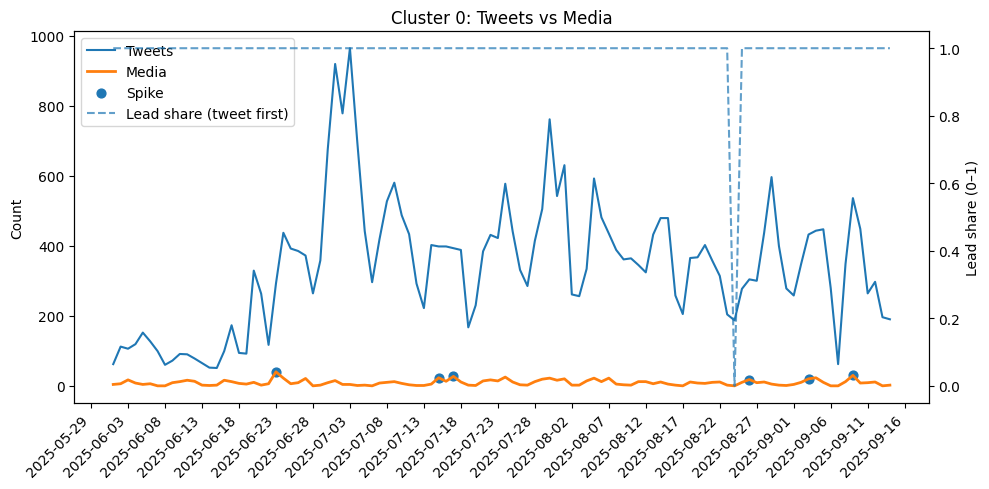

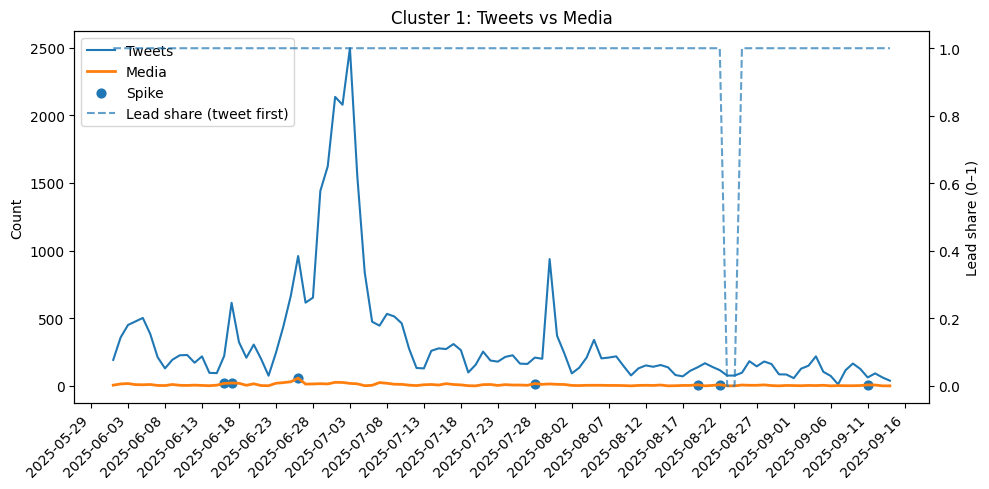

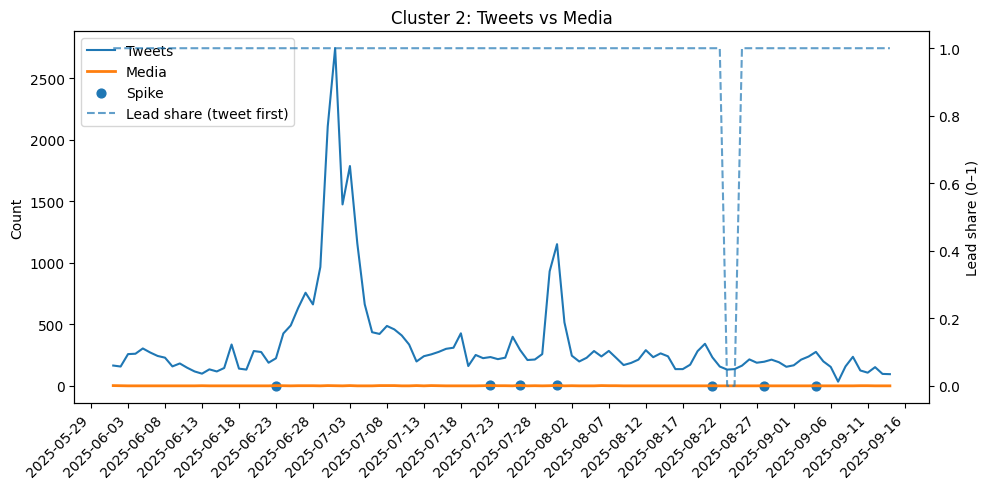

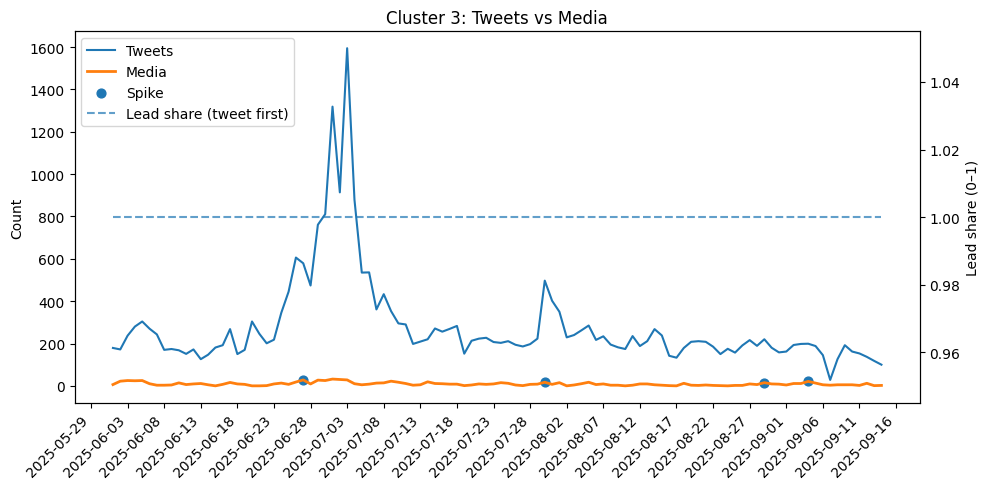

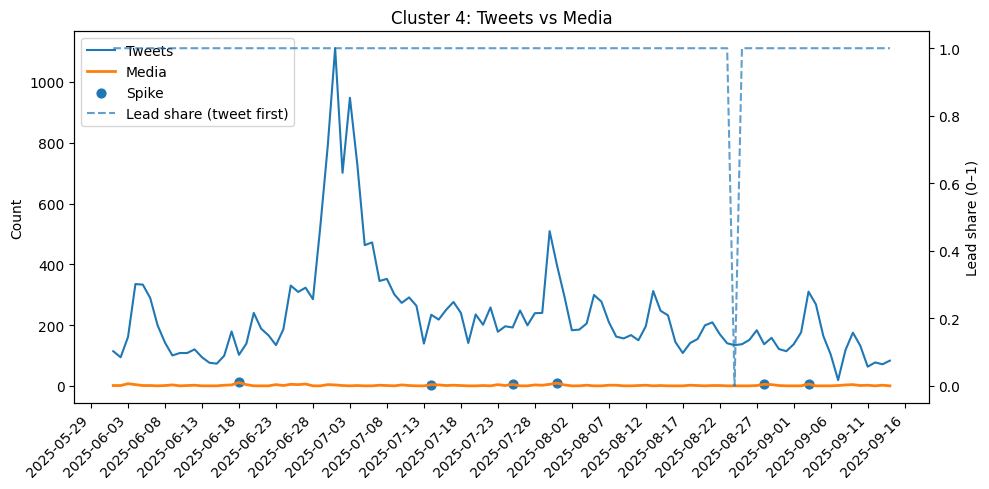

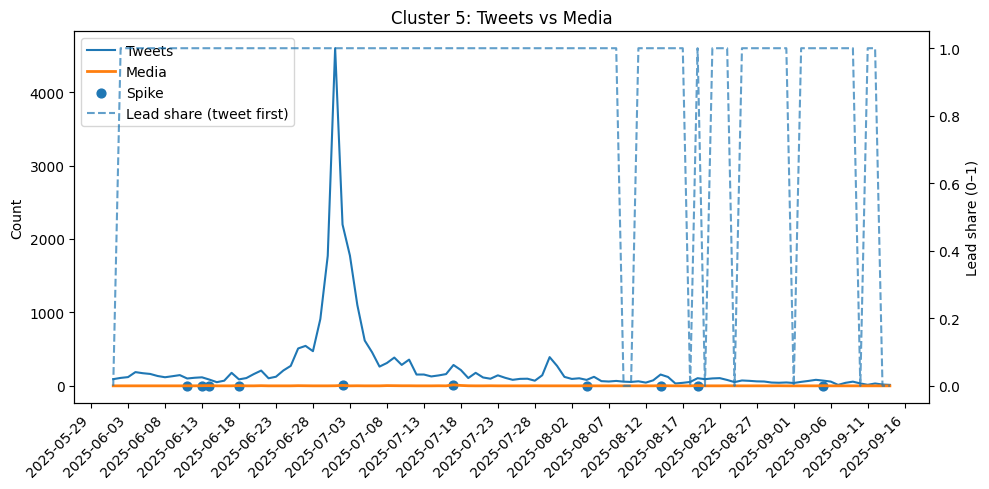

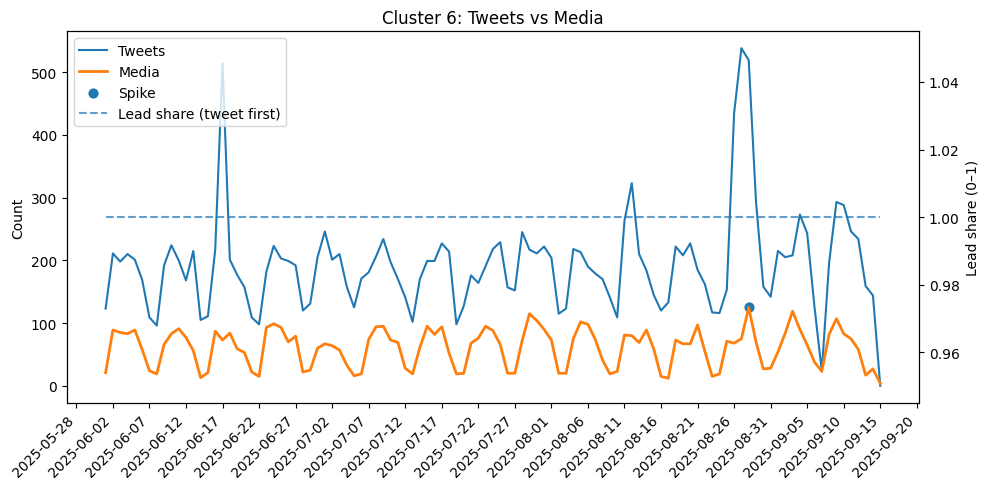

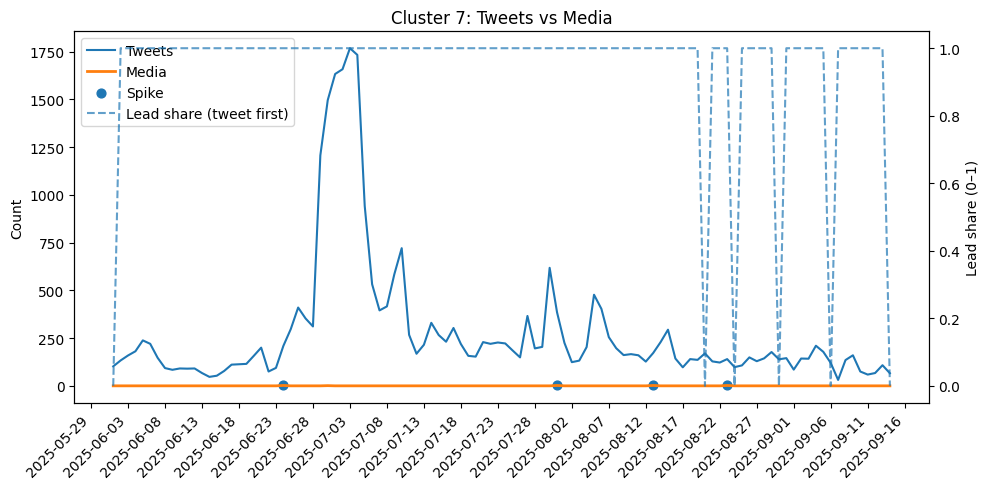

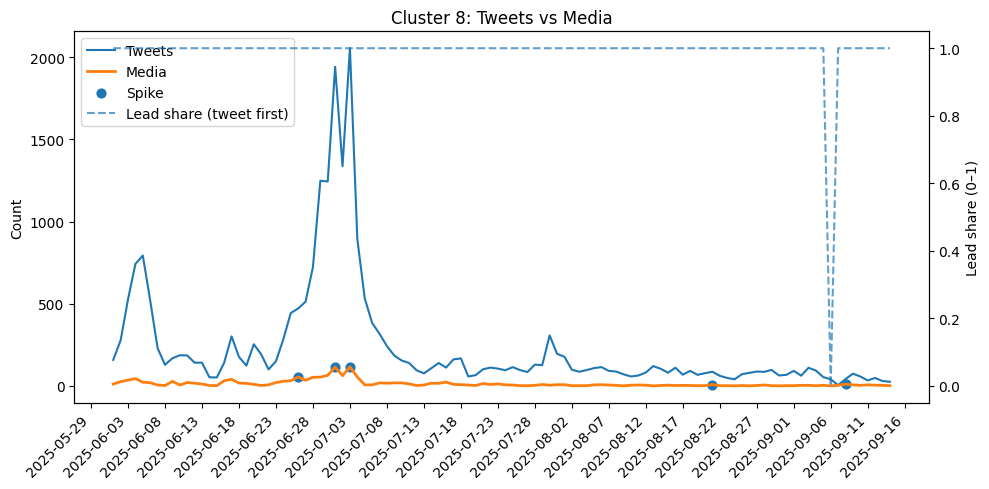

In [ ]:
#--------------PLOT ALL NARRATIVE CLUSTER TIMELINES-----------------------------
for cid in sorted(ts["cluster"].unique()):
    plot_narrative_timeline(ts, cid)
#-------------------------------------------------------------------------------

### SPIKE AUTHOR ATTRIBUTION BLOCK
Builds a utility for attributing narrative spikes to specific authors.

Used to explain WHY a spike happened in a narrative timeline—by identifying the top authors driving activity during that period and showing their roles and intensity.

For a given narrative cluster and a date window (e.g., around a spike in a timeline):

Filters the corpus to only:
  - that cluster
  - tweets (not media)
  - posts within the provided start/end dates

Aggregates tweet activity by author, computing:
- number of tweets in the window (tweet_count)
- total engagement
- first/last time they tweeted during the window

Optionally merges in influencer roles (Originator / Amplifier / Mixed) from the leaderboard.

Plots a horizontal bar chart showing the top contributors (default top 10), making it easy to see who drove the spike.

Returns the table of author stats for further analysis.

In [ ]:
#-----------------SPIKE AUTHOR ATTRIBUTION BLOCK--------------------------------
import pandas as pd
import matplotlib.pyplot as plt

def plot_top_authors_for_window(
    corpus,
    cluster_id,
    start_date,
    end_date,
    leaderboard_df=None,  # e.g. leaderboard_strict
    role_col="role",
    kind_col="_kind",
    time_col="time",
    cluster_col="cluster",
    author_col="author",
    engagement_col="engagement",
    k=10
):
    """
    For a given cluster and date window, show top authors driving activity.

    start_date / end_date can be 'YYYY-MM-DD' strings or pd.Timestamp.
    Assumes corpus[time_col] is tz-aware in UTC or tz-naive; we convert everything to UTC.
    """
    df = corpus.copy()

    # --- normalize time to UTC ---
    t = pd.to_datetime(df[time_col], errors="coerce")
    if t.dt.tz is None:
        t = t.dt.tz_localize("UTC")
    else:
        t = t.dt.tz_convert("UTC")
    df["_time_utc"] = t

    # parse start/end
    t_start = pd.to_datetime(start_date)
    t_end   = pd.to_datetime(end_date)

    if t_start.tzinfo is None:
        t_start = t_start.tz_localize("UTC")
    else:
        t_start = t_start.tz_convert("UTC")

    if t_end.tzinfo is None:
        # include entire end day
        t_end = t_end.tz_localize("UTC") + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)
    else:
        t_end = t_end.tz_convert("UTC")

    # --- filter to this cluster + tweets + time window ---
    mask = (
        (df[cluster_col] == cluster_id) &
        (df[kind_col] == "tweet") &
        (df["_time_utc"].between(t_start, t_end))
    )
    spike_tweets = df.loc[mask].copy()

    if spike_tweets.empty:
        print(f"No tweets found for cluster {cluster_id} between {t_start} and {t_end}.")
        return None

    # --- aggregate authors ---
    if engagement_col not in spike_tweets.columns:
        spike_tweets[engagement_col] = 0

    top_authors = (
        spike_tweets
        .groupby(author_col)
        .agg(
            tweet_count=(author_col, "size"),
            total_engagement=(engagement_col, "sum"),
            first_tweet_time=("_time_utc", "min"),
            last_tweet_time=("_time_utc", "max"),
        )
        .reset_index()
        .sort_values(["tweet_count", "total_engagement"], ascending=False)
    )

    # optional: merge roles
    if leaderboard_df is not None:
        if author_col not in leaderboard_df.columns:
            raise ValueError(f"leaderboard_df must have an '{author_col}' column.")
        if role_col not in leaderboard_df.columns:
            raise ValueError(f"leaderboard_df must have a '{role_col}' column.")

        top_authors = top_authors.merge(
            leaderboard_df[[author_col, role_col]],
            on=author_col,
            how="left"
        )
    else:
        top_authors[role_col] = ""

    # --- plot top k ---
    df_plot = top_authors.head(k).sort_values("tweet_count", ascending=True)

    plt.figure(figsize=(8, 4))
    plt.barh(df_plot[author_col], df_plot["tweet_count"])

    for i, (cnt, role) in enumerate(zip(df_plot["tweet_count"], df_plot[role_col])):
        label = str(cnt)
        if isinstance(role, str) and role:
            label += f" ({role})"
        plt.text(cnt + 0.3, i, label, va="center", fontsize=8)

    title_start = t_start.date()
    title_end   = (t_end.tz_convert("UTC")).date()
    plt.title(f"Cluster {cluster_id} – Top authors\n{title_start} to {title_end}")
    plt.xlabel("Tweet count in window")
    plt.tight_layout()
    plt.show()

    return top_authors  # return the table in case you want it
  #-----------------------------------------------------------------------------

### SPIKE-AUTHOR ATRRIBUTION INPUT BLOCK
concrete example / driver call for the spike-attribution function.

Allows user to actively explorer who the authors are behind spike in the narrative propagation timeline.

It calls plot_top_authors_for_window(...) for:
- cluster (user chooses which cluster)
- the window YYYY-MM-DD to YYYY-MM-DD (user chooses the time window)
- leadeerboard_df: optional input that lets the spike-attribution function pull in extra info about each author from your influencer leaderboard.
  - leaderboard_df
  - leaderboard_strict
  - None: raw tweet counts by author for that spike window, with no role annotations.

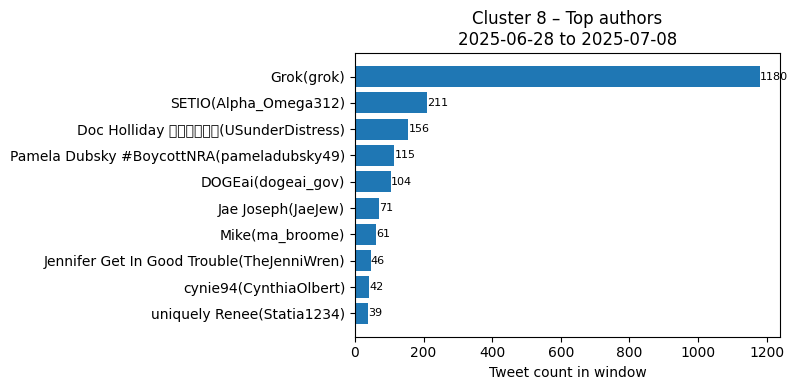

,author,tweet_count,total_engagement,first_tweet_time,last_tweet_time,role
1747,Grok(grok),1180,0,2025-06-28 00:37:54+00:00,2025-07-08 22:10:31+00:00,
3927,SETIO(Alpha_Omega312),211,0,2025-07-01 10:03:45+00:00,2025-07-03 11:36:26+00:00,
1283,Doc Holliday 🇺🇲🇺🇦🇨🇦(USunderDistress),156,0,2025-06-28 14:00:18+00:00,2025-07-05 02:51:23+00:00,
3359,Pamela Dubsky #BoycottNRA(pameladubsky49),115,0,2025-06-28 00:32:20+00:00,2025-07-06 00:23:15+00:00,
1060,DOGEai(dogeai_gov),104,0,2025-06-28 02:45:52+00:00,2025-07-07 18:52:55+00:00,
...,...,...,...,...,...,...
5498,🤘🏾h-town 𐚁 buckiin' 🐂(deifrankone),1,0,2025-07-04 05:24:47+00:00,2025-07-04 05:24:47+00:00,
5499,🥷(Harexlol),1,0,2025-07-03 05:52:43+00:00,2025-07-03 05:52:43+00:00,
5501,🦋Renee Perez🦋(ReneePerez),1,0,2025-06-29 06:22:18+00:00,2025-06-29 06:22:18+00:00,
5503,"🦬❌👑 Dr Red Bison, PhD @redbison.bsky ♀🏳️‍🌈🌻(RedBison)",1,0,2025-07-05 18:17:05+00:00,2025-07-05 18:17:05+00:00,


In [ ]:
#-------------------SPIKE-AUTHOR ATRRIBUTION INPUT BLOCK------------------------
# plot of specific spike in specific cluster at certain time range
 # Example: (SPIKE in Cluster 8 from "2025-06-28", "2025-07-08")
 # INPUT: start_date, end_date, leaderboard (strict or standard or none)
plot_top_authors_for_window(corpus, 8, "2025-06-28", "2025-07-08", leaderboard_df=None)

***
***
# TOP CENTRAL INFLUENCER NAMES AND METRICS BLOCK
Finds the most structurally central authors and outlets in the diffusion graphs and saves them as small ranking tables.

Identifies the key “hub” authors and outlets in the propagation network, based on network centrality, and exports them for use in briefs or dashboards.

- Loads the centrality outputs for the author→outlet graph and the URL graph.
- Defines build_top_table(...) to:
  - Filter nodes by prefix (author:: or outlet::),
  - Compute a simple hub_score from in-degree, out-degree, and betweenness,
  - Sort and keep the top k nodes with their centrality metrics.
- Builds:
  - top_authors – top central authors,
  - top_outlets – top central outlets,
- Saves both to CSV for reporting.

In [ ]:
#------------------------TOP CENTRAL INFLUENCER NAMES AND METRICS BLOCK---------
import pandas as pd

# Load if needed
cent_ao  = pd.read_csv("output/centrality_author_to_outlet.csv")   # author & outlet nodes
cent_url = pd.read_csv("output/centrality_url_graph.csv")          # url nodes

def _strip_prefix(s: pd.Series) -> pd.Series:
    return s.str.replace(r"^(author|outlet|url)::", "", regex=True)

def build_top_table(cent_df: pd.DataFrame, prefix: str, k: int = 15) -> pd.DataFrame:
    """
    prefix: 'author::', 'outlet::', or 'url::'
    Sorts by in_degree, out_degree, then betweenness (all desc).
    Adds a simple hub score for quick ranking.
    """
    d = cent_df[cent_df["node"].str.startswith(prefix)].copy()
    if d.empty:
        return pd.DataFrame(columns=["name","in_degree","out_degree","betweenness","hub_score"])

    # Simple composite to break ties (tune weights if needed)
    d["hub_score"] = d["in_degree"]*1.0 + d["out_degree"]*0.5 + d["betweenness"]*10.0

    cols = ["name","in_degree","out_degree","betweenness","hub_score"]
    out = (d.sort_values(["in_degree","out_degree","betweenness"], ascending=False)
             .head(k)
             .assign(name=lambda x: _strip_prefix(x["node"]))
             [cols]
             .reset_index(drop=True))
    return out

top_authors = build_top_table(cent_ao,  "author::", k=15)
top_outlets = build_top_table(cent_ao,  "outlet::", k=15)

# Save to CSVs for reporting
top_authors.to_csv("output/top_central_authors.csv", index=False)
top_outlets.to_csv("output/top_central_outlets.csv", index=False)

#-------------------------------------------------------------------------------

### TOP Central Authors” bar chart
Visualizes the most structurally central authors and outlets in the narrative propagation network.

Produces bar charts showing which authors and outlets are the key “hubs” or bridges in the narrative network, based on their network centrality.

Defines plot_top_centrality_bars(...) to:
  - Take a centrality table (like top_authors or top_outlets),
  - Sort by hub_score,
  - Plot a horizontal bar chart of hub_score by name.
- Then calls it twice:
  - Once for top authors,
  - Once for top outlets.

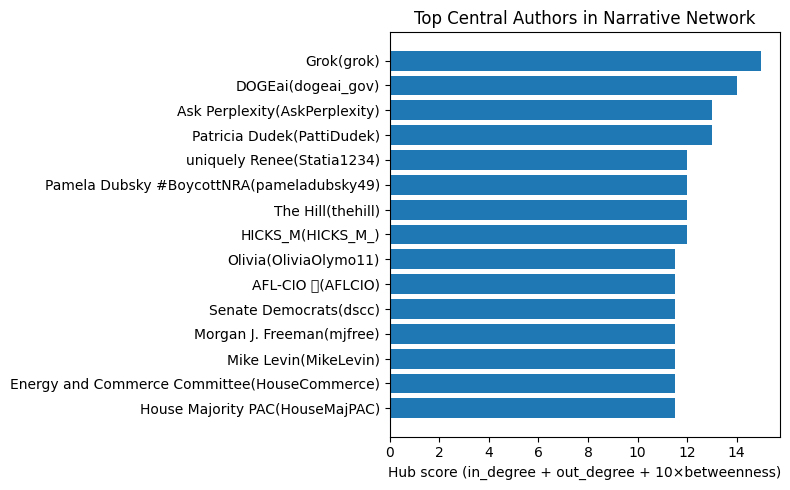

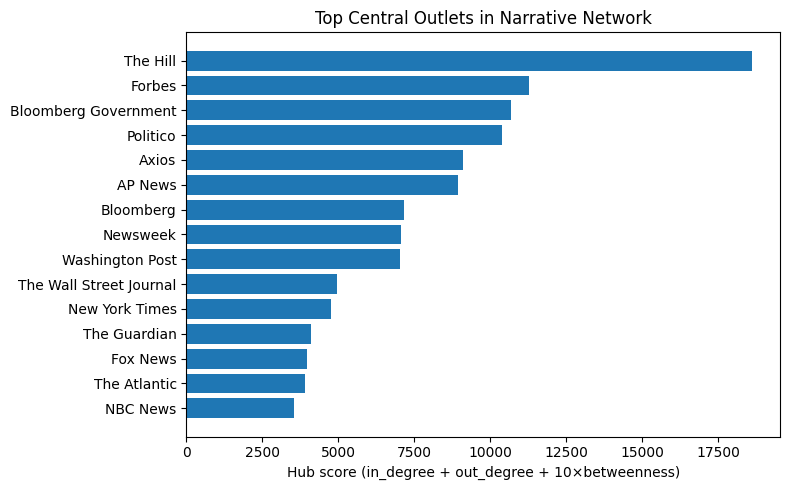

In [ ]:
#-----------TOP Central Authors” bar chart--------------------------------------
# which authors and outlets touch multiple narratives best through narrative propagation
# who are most structurally influential
# bridge multiple narratives because their content touches multiple topics
# connect/bridge narratives

import matplotlib.pyplot as plt

def plot_top_centrality_bars(df, title, k=15):
    df_plot = df.head(k).sort_values("hub_score", ascending=True)

    plt.figure(figsize=(8, 5))
    plt.barh(df_plot["name"], df_plot["hub_score"])
    plt.xlabel("Hub score (in_degree + out_degree + 10×betweenness)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_top_centrality_bars(top_authors, "Top Central Authors in Narrative Network")
plot_top_centrality_bars(top_outlets, "Top Central Outlets in Narrative Network")